In [3]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from utils.utils_read import load_results, _sanitize_answer
from utils.utils_graph import make_balanced_matrix


BASE_PATH = Path(
    "/data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/"
)

# Map label -> run_name (folder under BASE_PATH).
RUNS = {
    "run_25_roi_ablation_baseline": "run_25_roi_ablation_baseline",
    "run_25_roi_circling_no_text": "run_25_roi_circling_no_text",
    # "run_25_roi_circling_no_text_layout_position": "run_25_roi_circling_no_text_layout_position",         
}

# If non-empty, compute metrics per model_id in this list.
MODELS: list[str] = []


def _build_eval_df(base_path: Path, run_name: str) -> pd.DataFrame | None:
    run_folder = Path(run_name)
    results_dir = base_path / run_folder / f"results_{run_folder}_sanitized"
    model_cols = sorted(p.stem.replace("_val", "") for p in results_dir.glob("*_val.json"))
    if not model_cols:
        print(f"Skipping {run_name}: no model results in {results_dir}")
        return None

    df = load_results(
        base_path,
        run_folder,
        merge_model_answers=True,
        model_answers_wide=True,
        cache=True,
        add_sim_metadata=True,
    )

    model_cols = [c for c in model_cols if c in df.columns]
    if not model_cols:
        print(f"Skipping {run_name}: no matching model columns in data")
        return None

    df["answer"] = df["answer"].apply(
        lambda a: _sanitize_answer(a, max_prefix_chars=None)
    )

    id_cols = [
        c
        for c in [
            "idx",
            "question_id",
            "category",
            "sub_category",
            "num_objects",
            "object_count",
            "answer",
            "mode_test",
            "mode_val",
            "mode",
        ]
        if c in df.columns
    ]

    eval_df = df.melt(
        id_vars=id_cols,
        value_vars=model_cols,
        var_name="model_id",
        value_name="model_answer",
    )

    valid = eval_df["model_answer"].notna() & eval_df["answer"].notna()
    eval_df["is_correct"] = pd.NA
    eval_df.loc[valid, "is_correct"] = (
        eval_df.loc[valid, "model_answer"] == eval_df.loc[valid, "answer"]
    )

    return eval_df

base_path = BASE_PATH


In [4]:
import pandas as pd

run_acc = []

runs = [
    "run_25_roi_ablation_baseline",
    "run_25_roi_circling_no_text",
    "run_25_roi_circling_no_text_layout_position",
    "run_25_roi_circling_text",
    "run_25_roi_circling_text_layout_position",
    "run_25_no_roi_circling_yes_text_layout_position",
    "run_25_no_roi_circling_no_text_layout_position"
]

for run_name in runs:
    print(f"Processing run: {run_name}")
    eval_df = _build_eval_df(base_path, run_name)

    eval_df = eval_df[eval_df['object_count'] >= 5]

    model_macro = []

    for model_id in eval_df["model_id"].unique():
        sub_acc = []

        for sub_cat in eval_df["sub_category"].unique():
            df = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]
            vc = df["is_correct"].value_counts()
            acc = vc.get(True, 0) / vc.sum()
            sub_acc.append(acc)

        model_macro.append(sum(sub_acc) / len(sub_acc))

    run_acc.append({
        "run": run_name,
        "macro_accuracy": sum(model_macro) / len(model_macro)
    })

plot_df = pd.DataFrame(run_acc)


Processing run: run_25_roi_ablation_baseline
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Processing run: run_25_roi_circling_no_text
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text/merged_results.pkl
Cache is missing required columns: ['object_count', 'visible_pixels_interested_object']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:02<00:00, 387.46it/s]


Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

100%|██████████| 996/996 [00:00<00:00, 8499.06it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

...

100%|██████████| 996/996 [00:00<00:00, 8619.64it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Processing run: run_25_no_roi_circling_no_text_layout_position
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_no_roi_circling_no_text_layout_position/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 8393.29it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [ ]:
plot_df

,idx,question_id,category,sub_category,object_count,answer,mode_test,mode_val,model_id,model_answer,is_correct
0,3483_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,8,A,image-only,image-only,Aquila-VL-2B,B,False
1,5545_i,F_MASS_OBJECT,material_understanding,mass,10,B,image-only,image-only,Aquila-VL-2B,C,False
3,5099_g,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,10,A,general,general,Aquila-VL-2B,NaN,<NA>
4,3096_i,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,7,C,image-only,image-only,Aquila-VL-2B,A,False
5,4507_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_METRIC...,material_understanding,young_modulus,9,A,image-only,image-only,Aquila-VL-2B,B,False
...,...,...,...,...,...,...,...,...,...,...,...
47801,1884_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,5,D,image-only,image-only,vila-1.5-8b,A,False
47803,3154_g,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_1,material_understanding,material_identification,7,D,general,general,vila-1.5-8b,A,False
47805,3586_i,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_3,material_understanding,material_identification,8,B,image-only,image-only,vila-1.5-8b,A,False
47806,3609_i,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,8,A,image-only,image-only,vila-1.5-8b,A,True


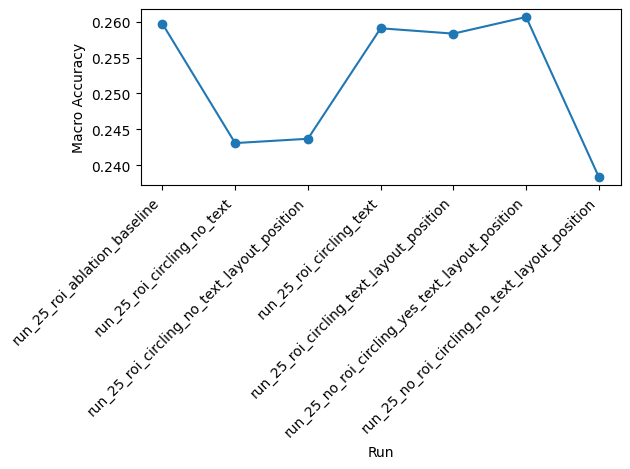

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(plot_df["run"], plot_df["macro_accuracy"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro Accuracy")
plt.xlabel("Run")
plt.tight_layout()
plt.show()

In [13]:
rows = []

for run_name in runs:
    eval_df = _build_eval_df(base_path, run_name)

    for model_id in eval_df["model_id"].unique():
        sub_acc = []

        for sub_cat in eval_df["sub_category"].unique():
            df = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]
            vc = df["is_correct"].value_counts()
            acc = vc.get(True, 0) / vc.sum()
            sub_acc.append(acc)

        rows.append({
            "run": run_name,
            "model": model_id,
            "macro_accuracy": sum(sub_acc) / len(sub_acc)
        })

plot_df = pd.DataFrame(rows)


Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 8066.70it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text_layout_position/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 8759.50it/s]

...

100%|██████████| 996/996 [00:00<00:00, 8406.42it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_no_roi_circling_no_text_layout_position/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 7844.18it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [14]:
len(eval_df["model_id"].unique())

48

In [15]:
eval_df

,idx,question_id,category,sub_category,object_count,answer,mode_test,mode_val,model_id,model_answer,is_correct
0,3483_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,8,A,image-only,image-only,Aquila-VL-2B,B,False
1,5545_i,F_MASS_OBJECT,material_understanding,mass,10,B,image-only,image-only,Aquila-VL-2B,C,False
2,727_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,3,C,image-only,image-only,Aquila-VL-2B,A,False
3,5099_g,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,10,A,general,general,Aquila-VL-2B,NaN,<NA>
4,3096_i,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,7,C,image-only,image-only,Aquila-VL-2B,A,False
...,...,...,...,...,...,...,...,...,...,...,...
47803,3154_g,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_1,material_understanding,material_identification,7,D,general,general,vila-1.5-8b,A,False
47804,272_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,2,A,general,general,vila-1.5-8b,A,True
47805,3586_i,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_3,material_understanding,material_identification,8,B,image-only,image-only,vila-1.5-8b,A,False
47806,3609_i,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,8,A,image-only,image-only,vila-1.5-8b,A,True


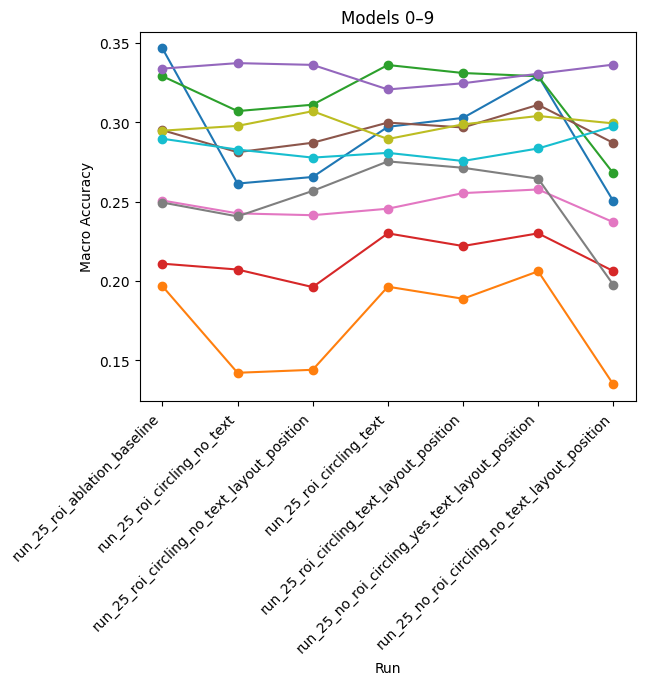

<Figure size 800x600 with 0 Axes>

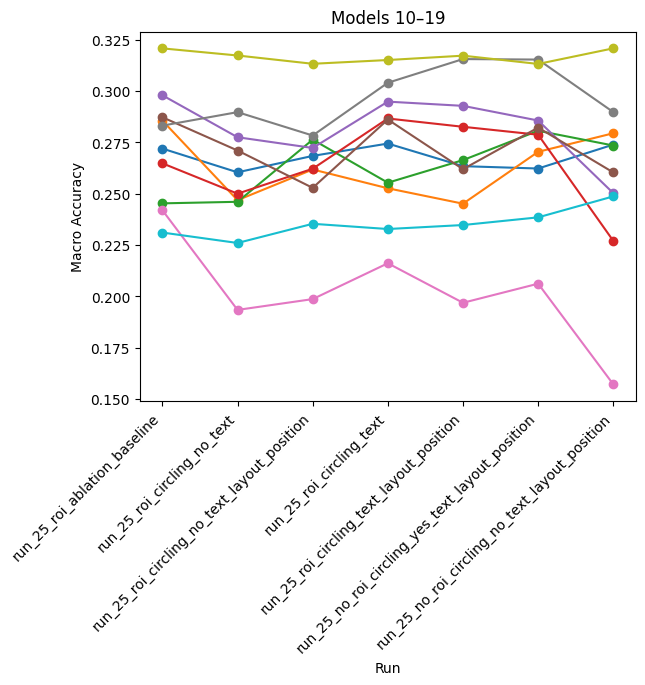

<Figure size 800x600 with 0 Axes>

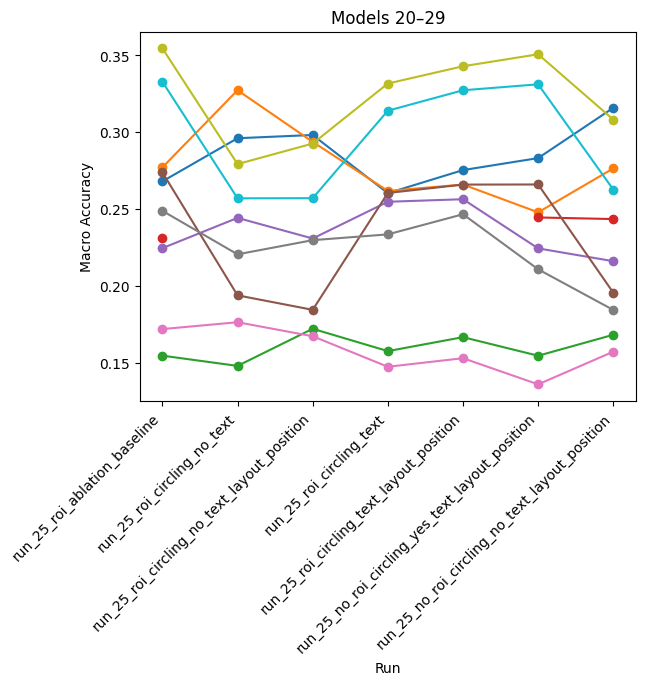

<Figure size 800x600 with 0 Axes>

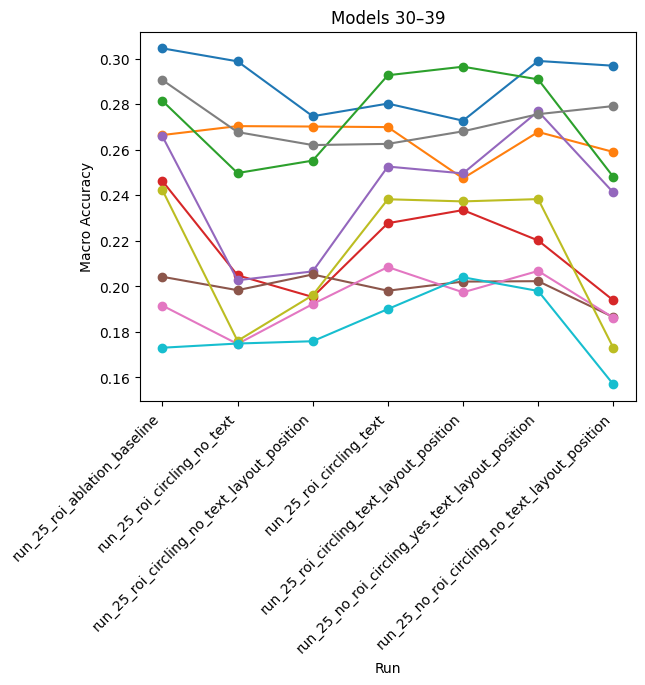

<Figure size 800x600 with 0 Axes>

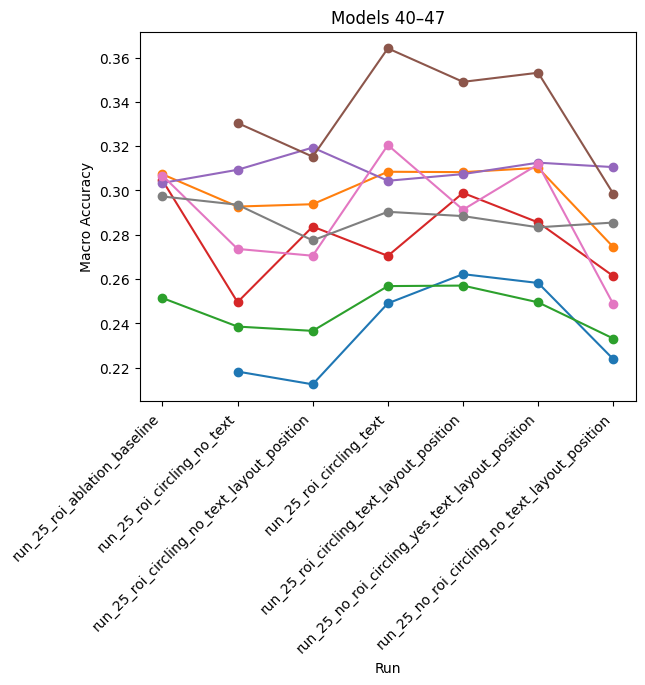

<Figure size 800x600 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt
import math

models = list(plot_df["model"].unique())
runs = list(plot_df["run"].unique())

models_per_fig = 10
n_figs = math.ceil(len(models) / models_per_fig)

for i in range(n_figs):
    model_chunk = models[i * models_per_fig:(i + 1) * models_per_fig]
    df_chunk = plot_df[plot_df["model"].isin(model_chunk)]

    plt.figure()

    for model, df_m in df_chunk.groupby("model"):
        df_m = (
        df_m.set_index("run")
            .reindex(runs)        # missing runs → NaN
            .reset_index()
       )
        plt.plot(df_m["run"], df_m["macro_accuracy"], marker="o", label=model)

    plt.xlabel("Run")
    plt.ylabel("Macro Accuracy")
    plt.title(f"Models {i*models_per_fig}–{min((i+1)*models_per_fig, len(models))-1}")
    plt.xticks(rotation=45, ha="right")
    plt.figure(figsize=(8, 6))  # width, height in inches
    # plt.legend()
    plt.tight_layout()
    plt.show()


In [24]:
rows = []

for run_name in runs:
    eval_df = _build_eval_df(base_path, run_name)

    for model_id in eval_df["model_id"].unique():
        for sub_cat in eval_df["sub_category"].unique():
            df = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]

            if len(df) == 0:
                continue

            vc = df["is_correct"].value_counts()
            acc = vc.get(True, 0) / vc.sum()

            rows.append({
                "run": run_name,
                "model": model_id,
                "sub_category": sub_cat,
                "accuracy": acc
            })

cat_plot_df = pd.DataFrame(rows)


Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 7921.46it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text_layout_position/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 8733.99it/s]

...

100%|██████████| 996/996 [00:00<00:00, 8140.91it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_no_roi_circling_no_text_layout_position/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 8381.17it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [ ]:
import matplotlib.pyplot as plt

runs = list(cat_plot_df["run"].unique())
models = list(cat_plot_df["model"].unique())

for model in models:
    df_m = cat_plot_df[cat_plot_df["model"] == model]

    plt.figure(figsize=(8, 6))

    for sub_cat, df_c in df_m.groupby("sub_category"):
        df_c = (
            df_c.set_index("run")
                .reindex(runs)
                .reset_index()
        )

        plt.plot(
            df_c["run"],
            df_c["accuracy"],
            marker="o",
            label=sub_cat
        )

    plt.title(f"Category accuracy over runs – {model}")
    plt.xlabel("Run")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

runs = list(cat_plot_df["run"].unique())
models = list(cat_plot_df["model"].unique())

# for model in models:
df_m = cat_plot_df[cat_plot_df["model"] == model]

plt.figure(figsize=(8, 6))

for sub_cat, df_c in df_m.groupby("sub_category"):
    df_c = (
        df_c.set_index("run")
            .reindex(runs)
            .reset_index()
    )

    plt.plot(
        df_c["run"],
        df_c["accuracy"],
        marker="o",
        label=sub_cat
    )

plt.title(f"Category accuracy over runs – {model}")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
cat_plot_df

,run,model,sub_category,accuracy
0,run_25_roi_ablation_baseline,Aquila-VL-2B,young_modulus,0.367925
1,run_25_roi_ablation_baseline,Aquila-VL-2B,mass,0.364486
2,run_25_roi_ablation_baseline,Aquila-VL-2B,density,0.057692
3,run_25_roi_ablation_baseline,Aquila-VL-2B,poisson_ratio,0.461538
4,run_25_roi_ablation_baseline,Aquila-VL-2B,material_identification,0.481481
...,...,...,...,...
1645,run_25_no_roi_circling_no_text_layout_position,vila-1.5-8b,young_modulus,0.252525
1646,run_25_no_roi_circling_no_text_layout_position,vila-1.5-8b,mass,0.180000
1647,run_25_no_roi_circling_no_text_layout_position,vila-1.5-8b,density,0.290000
1648,run_25_no_roi_circling_no_text_layout_position,vila-1.5-8b,poisson_ratio,0.403061


In [33]:
rows = []

for run_name in runs:
    eval_df = _build_eval_df(base_path, run_name)

    for model_id in eval_df["model_id"].unique():
        for sub_cat in eval_df["sub_category"].unique():
            df = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]

            if len(df) == 0:
                continue

            vc = df["is_correct"].value_counts()
            acc = vc.get(True, 0) / vc.sum()

            rows.append({
                "run": run_name,
                "model": model_id,
                "sub_category": sub_cat,
                "accuracy": acc
            })

cat_plot_df = pd.DataFrame(rows)


Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 7736.00it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text_layout_position/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 7614.32it/s]

...

100%|██████████| 996/996 [00:00<00:00, 7228.16it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_no_roi_circling_no_text_layout_position/merged_results.pkl
Cache is missing required columns: ['visible_pixels_interested_object', 'MiniCPM-V2']
Processing columns...
Reading scenes simulation...


100%|██████████| 996/996 [00:00<00:00, 7678.26it/s]

Merging model answers...
                                                                                                                                                                               simulation_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [54]:
eval_df

,idx,question_id,category,sub_category,object_count,answer,mode_test,mode_val,model_id,model_answer,is_correct
0,3483_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,8,A,image-only,image-only,Aquila-VL-2B,B,False
1,5545_i,F_MASS_OBJECT,material_understanding,mass,10,B,image-only,image-only,Aquila-VL-2B,C,False
2,727_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,3,C,image-only,image-only,Aquila-VL-2B,A,False
3,5099_g,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,10,A,general,general,Aquila-VL-2B,NaN,<NA>
4,3096_i,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,7,C,image-only,image-only,Aquila-VL-2B,A,False
...,...,...,...,...,...,...,...,...,...,...,...
47803,3154_g,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_1,material_understanding,material_identification,7,D,general,general,vila-1.5-8b,A,False
47804,272_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,2,A,general,general,vila-1.5-8b,A,True
47805,3586_i,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_3,material_understanding,material_identification,8,B,image-only,image-only,vila-1.5-8b,A,False
47806,3609_i,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,8,A,image-only,image-only,vila-1.5-8b,A,True


In [53]:
stats = (
    eval_df
    .groupby(["model_id", "sub_category", "run"])
    .agg(
        mean=("is_correct", "mean"),
        std=("is_correct", "std")
    )
    .reset_index()
)


import matplotlib.pyplot as plt
import numpy as np

runs = stats["run"].unique()
models = ["Aquila-VL-2B"]

for model in models:
    df_m = stats[stats["model_id"] == model]
    plt.figure(figsize=(8, 6))

    for sub_cat, df_c in df_m.groupby("sub_category"):
        df_c = (
            df_c.set_index("run")
                .reindex(runs)
                .reset_index()
        )

        x = np.arange(len(df_c))

        plt.errorbar(
            x,
            df_c["mean"],
            yerr=df_c["std"],
            marker="o",
            capsize=3,
            linewidth=1,
            label=sub_cat
        )

    plt.xticks(x, runs, rotation=45, ha="right")
    plt.xlabel("Run")
    plt.ylabel("Accuracy")
    plt.title(f"Category accuracy over runs – {model}")
    plt.legend()
    plt.tight_layout()
    plt.show()


KeyError: 'run'

In [51]:
cat_plot_df.groupby(["model", "sub_category", "run"]).size().value_counts()


1    1650
Name: count, dtype: int64

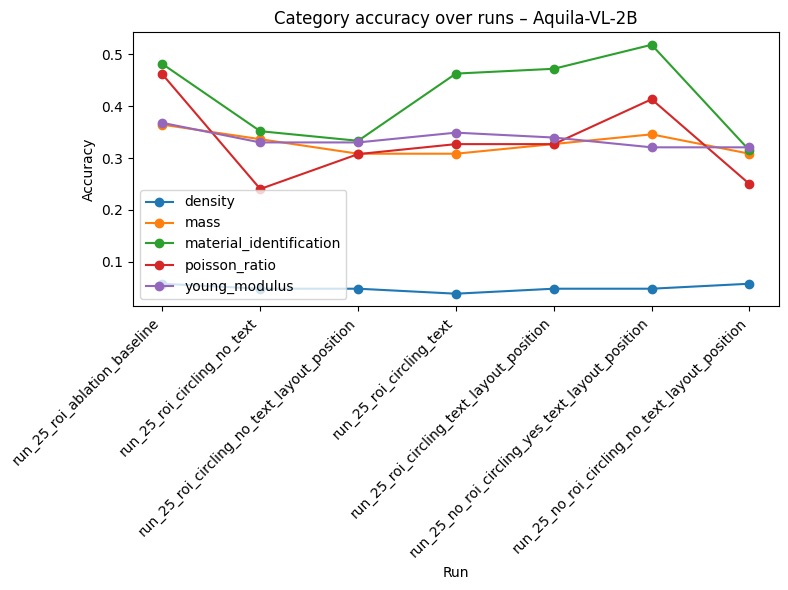

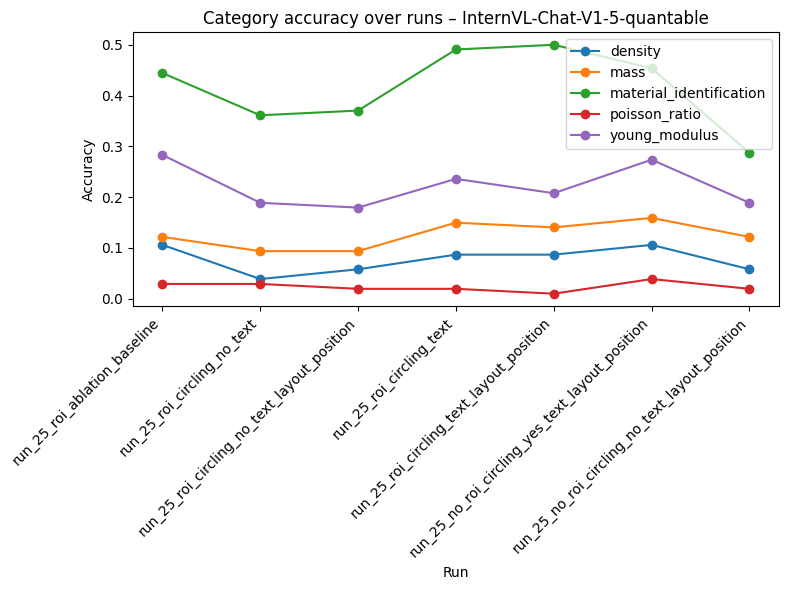

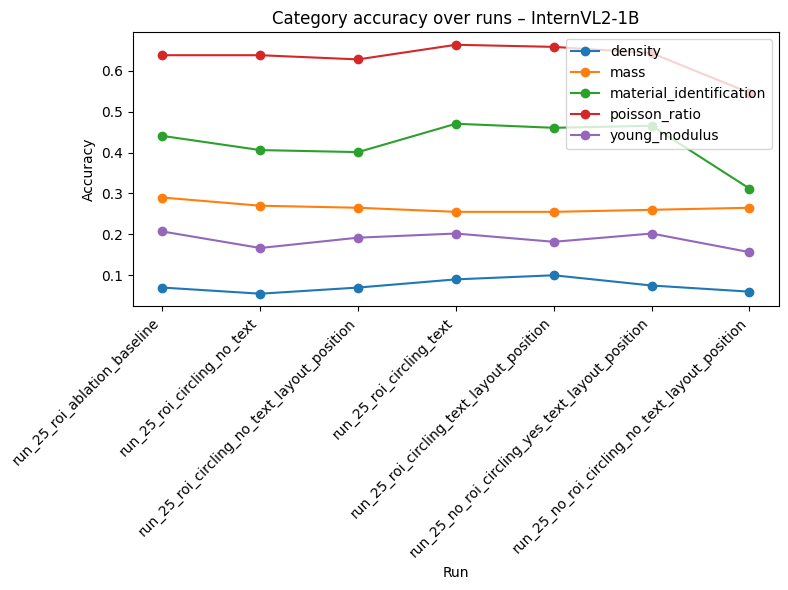

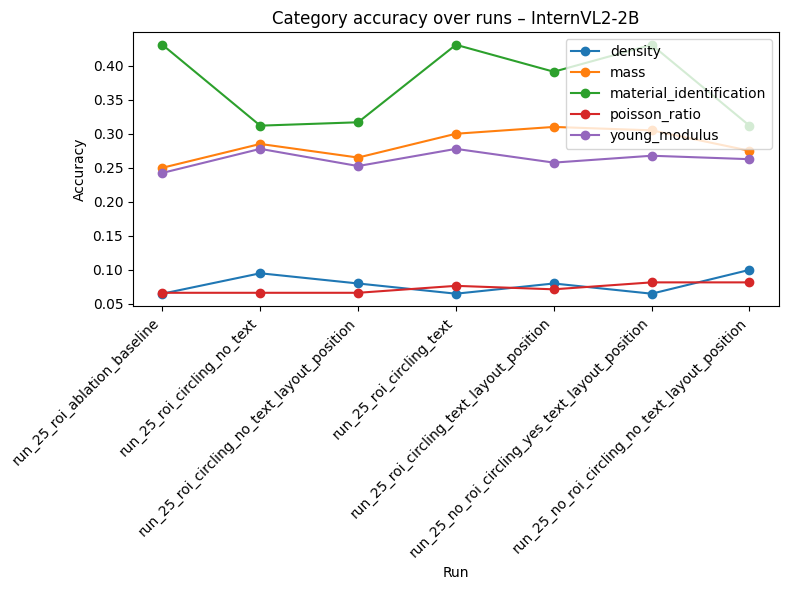

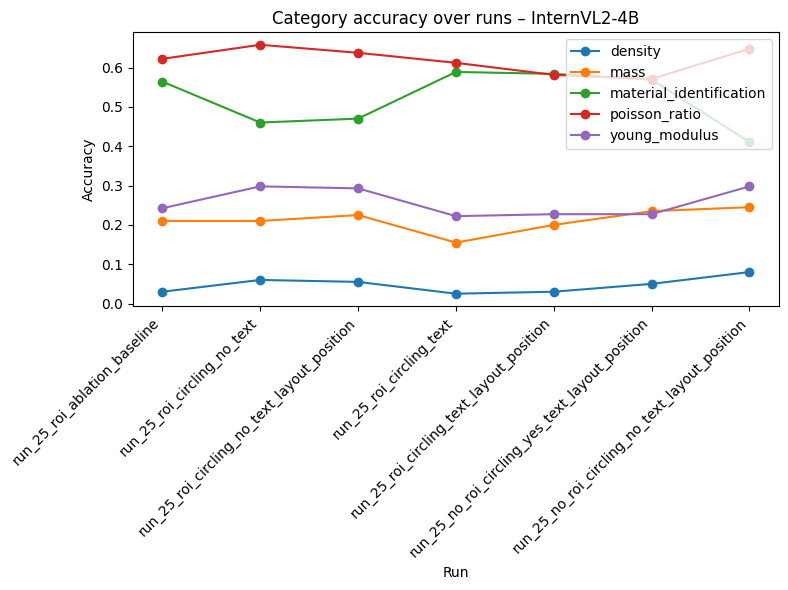

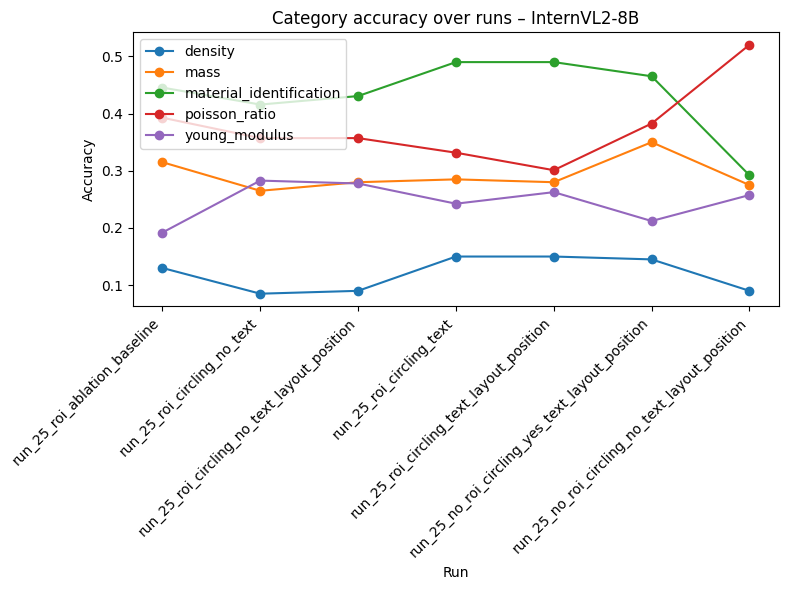

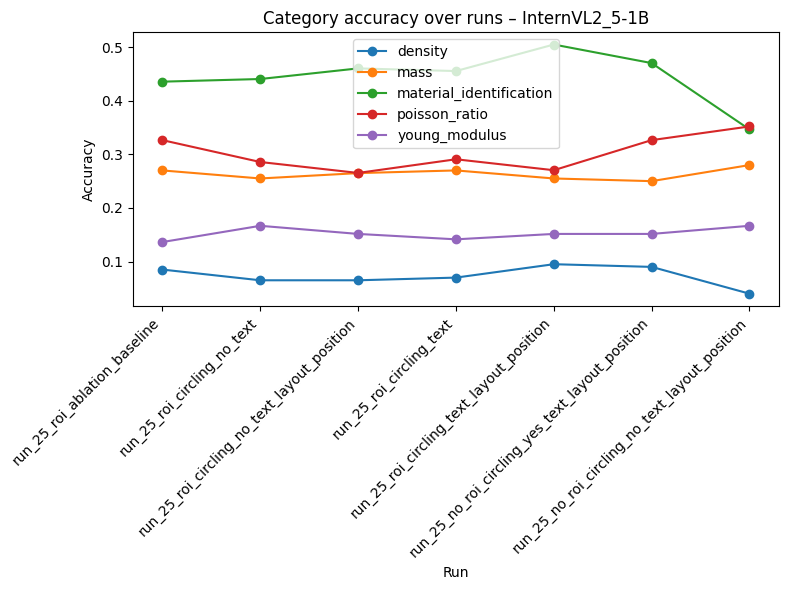

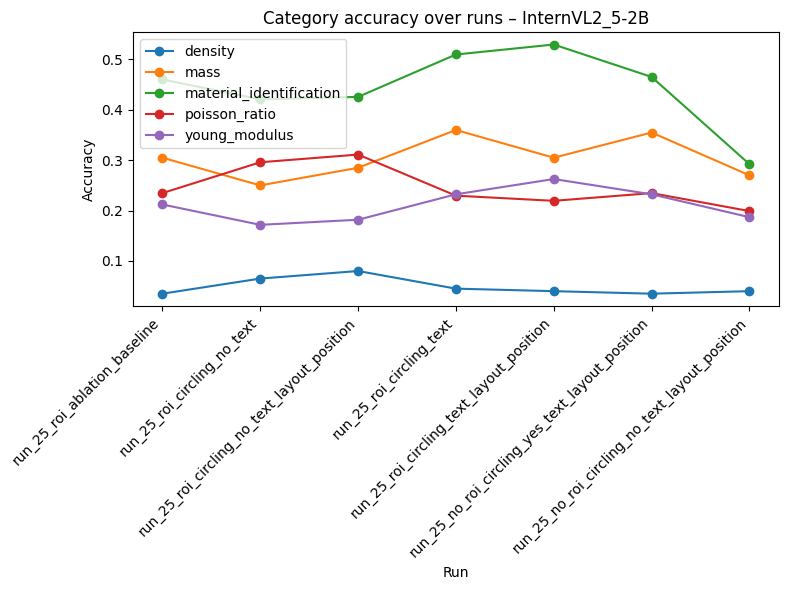

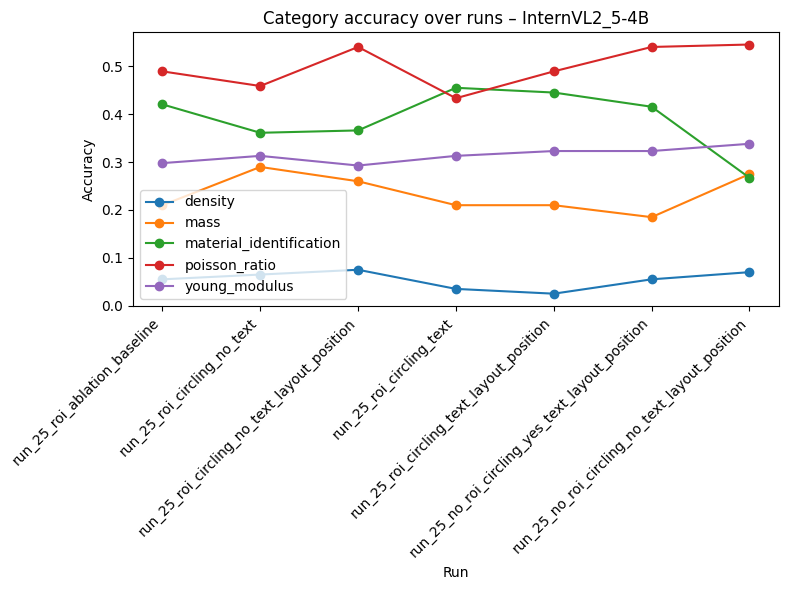

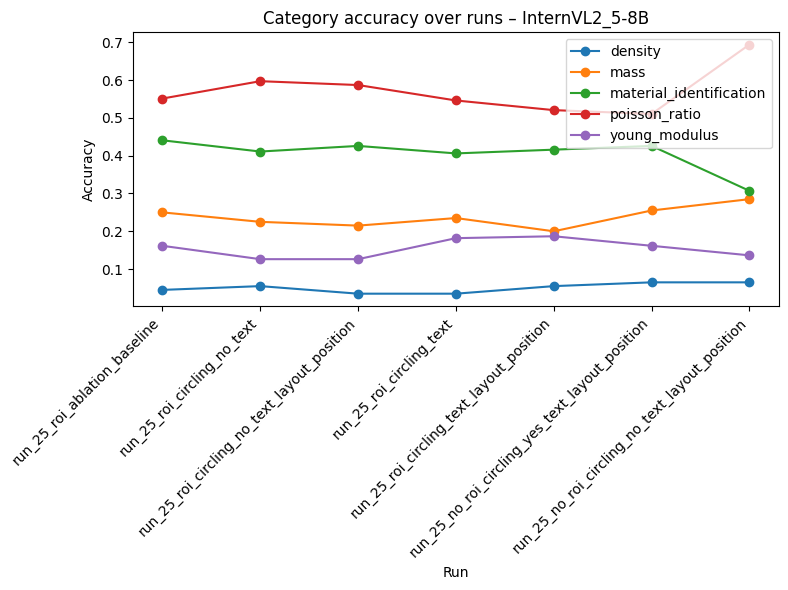

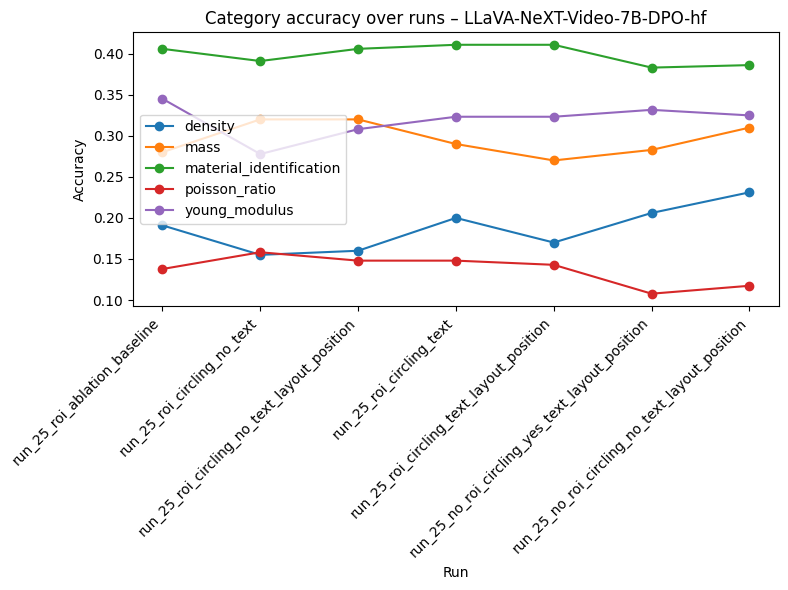

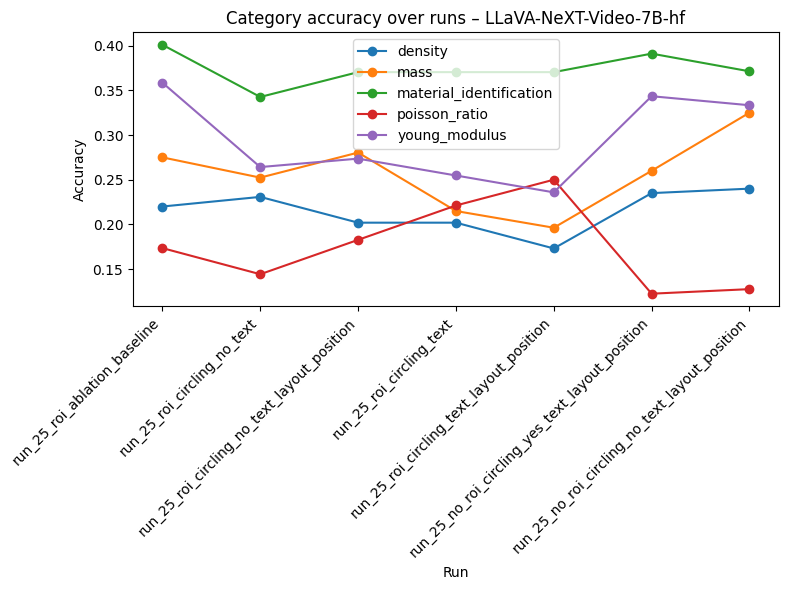

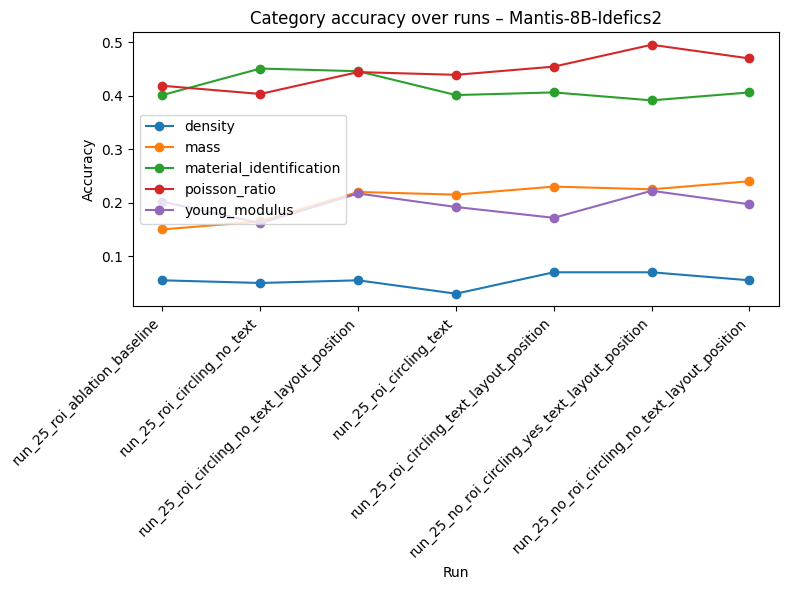

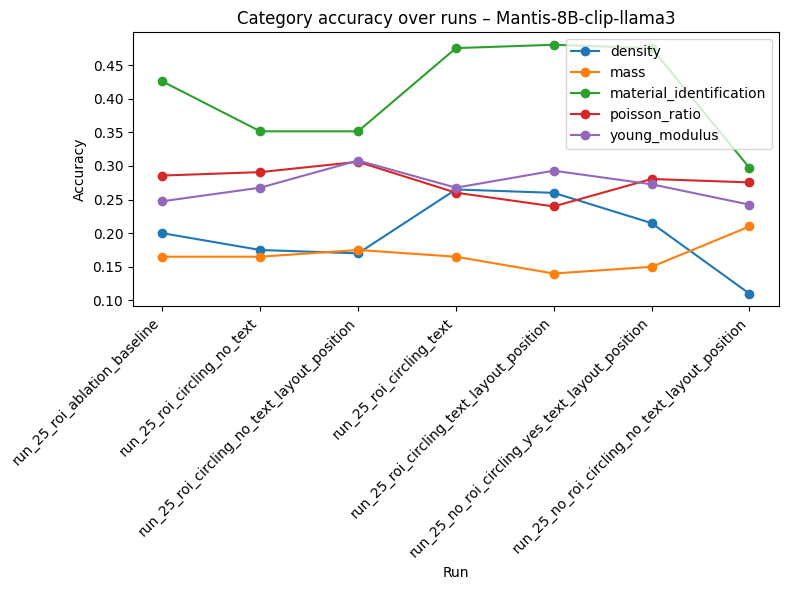

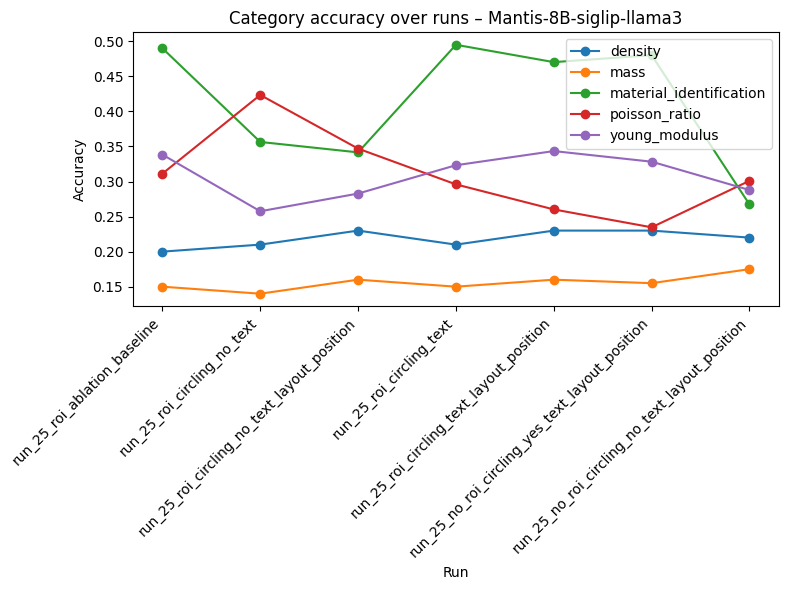

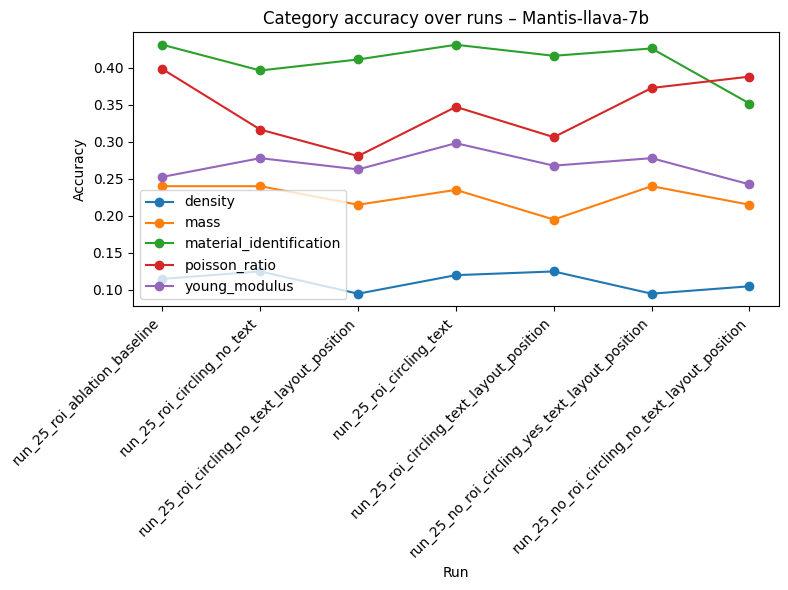

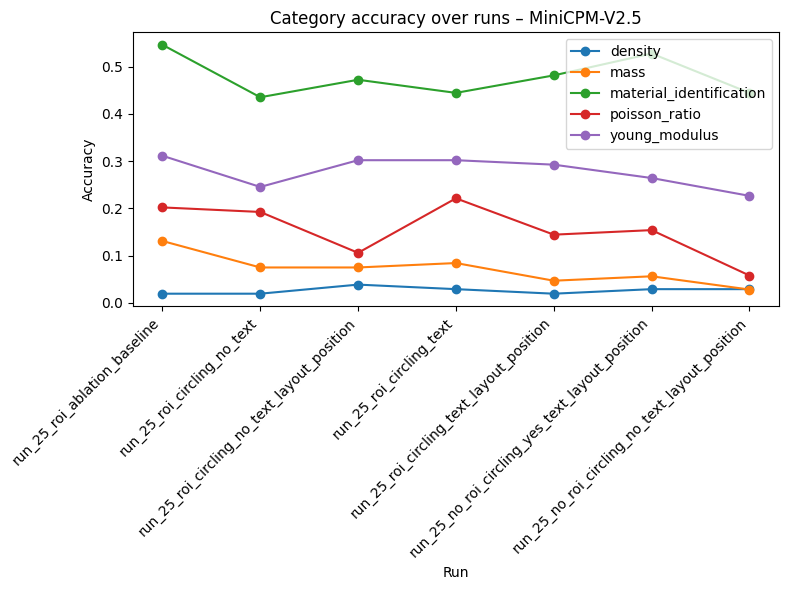

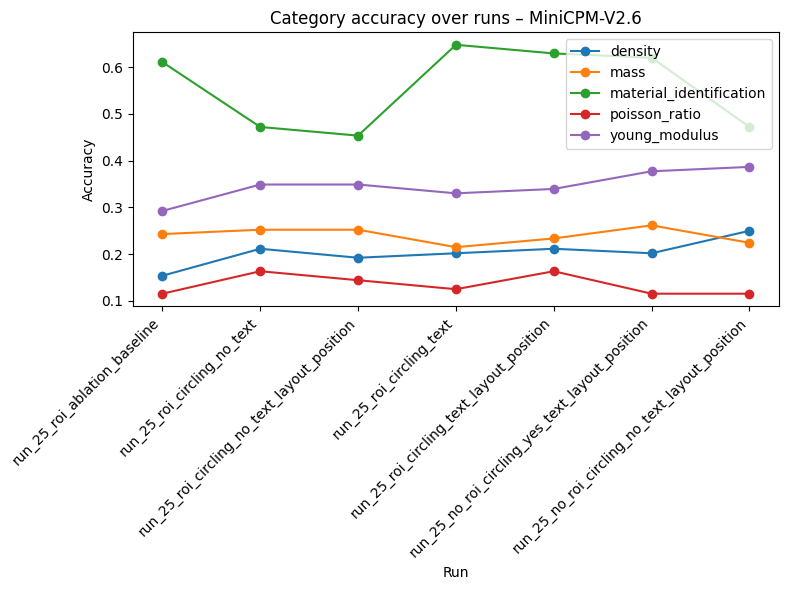

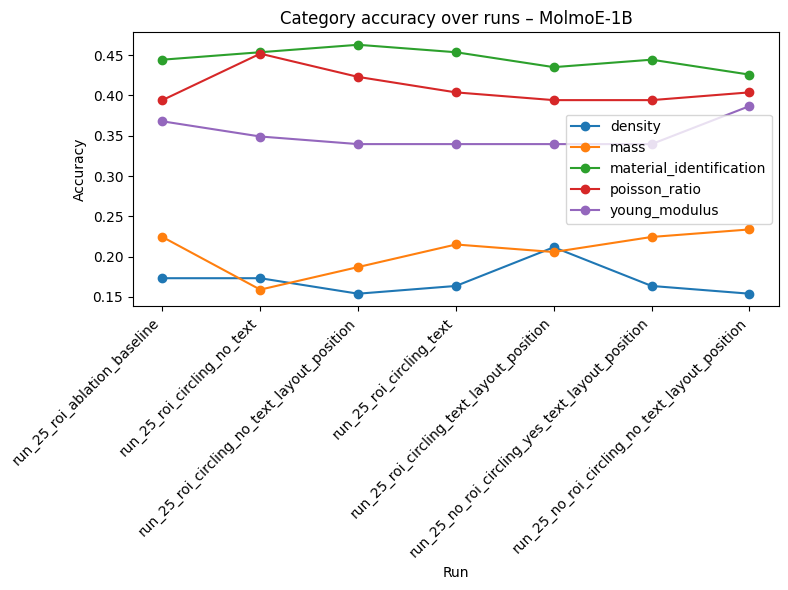

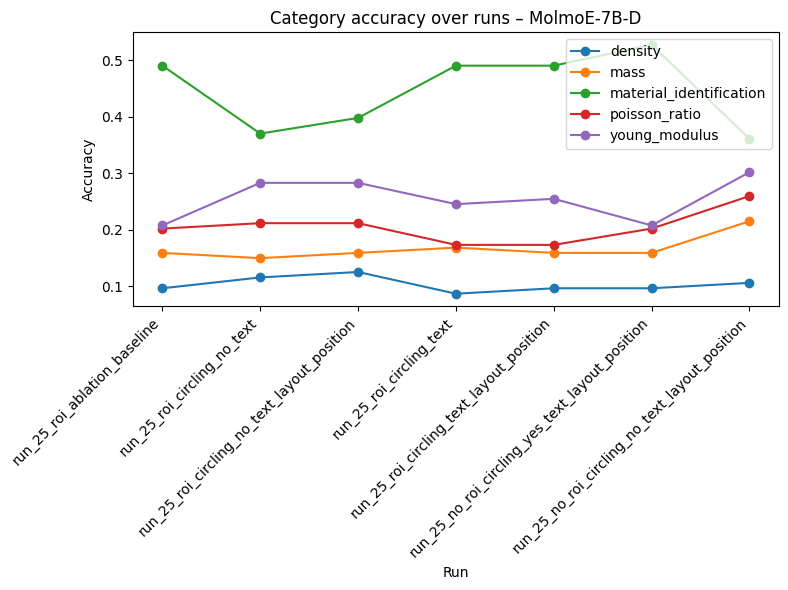

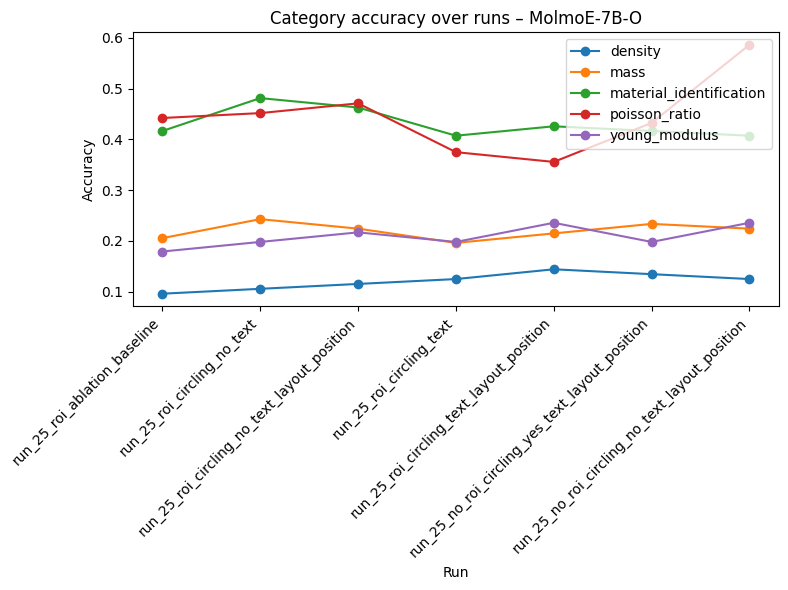

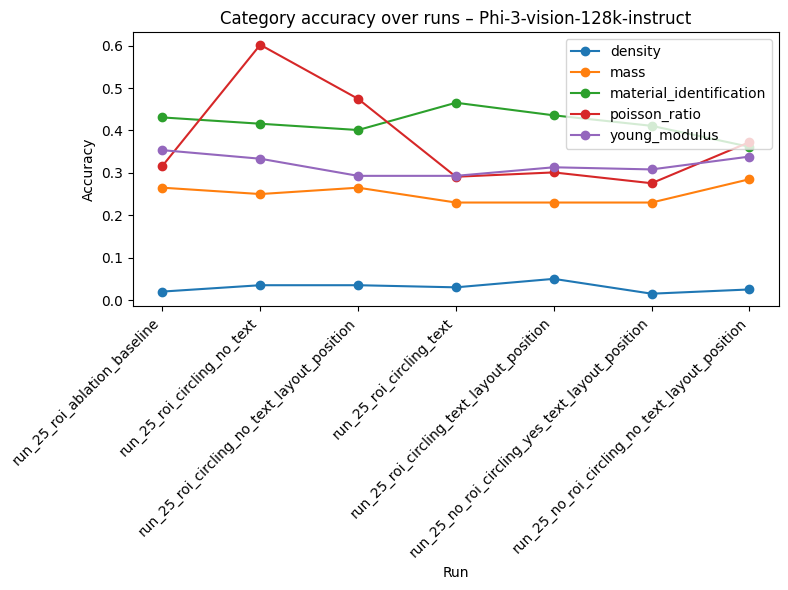

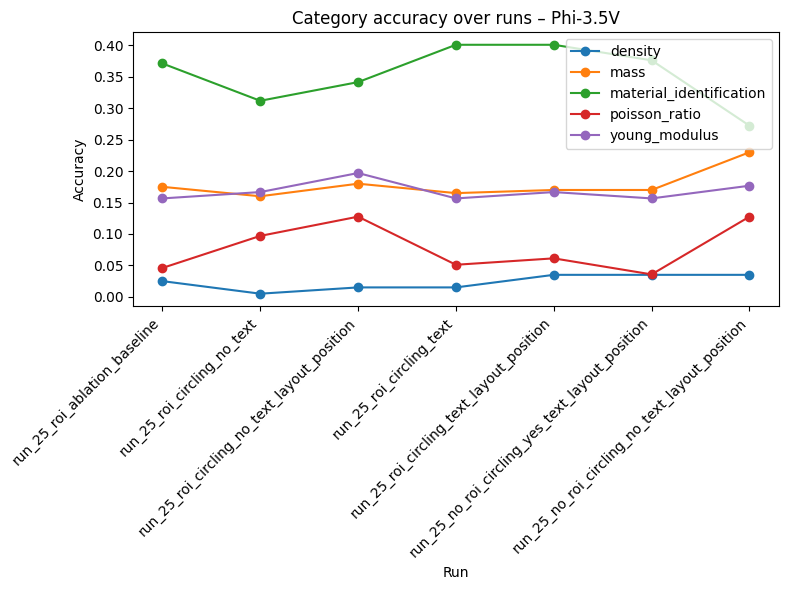

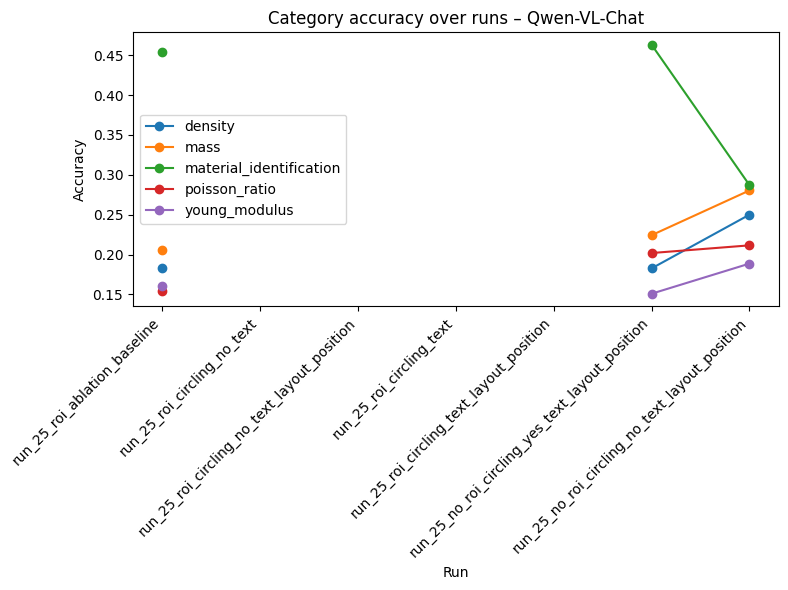

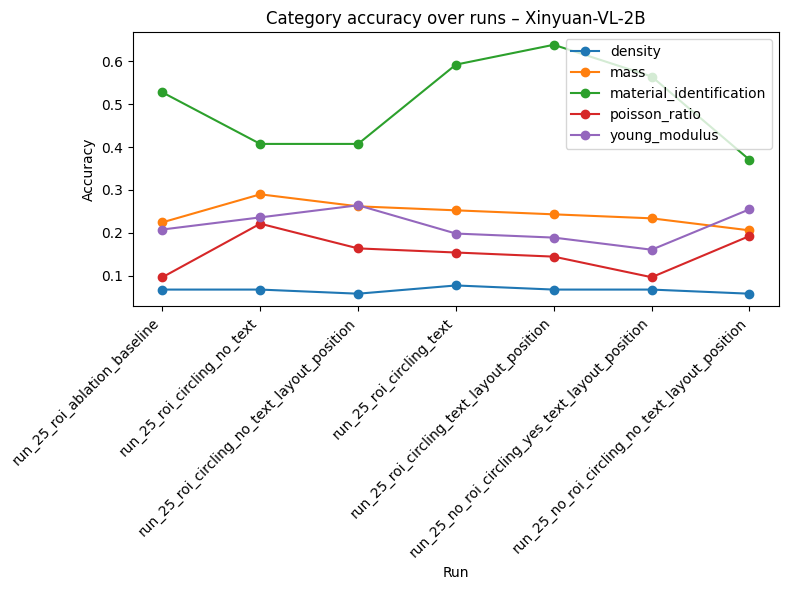

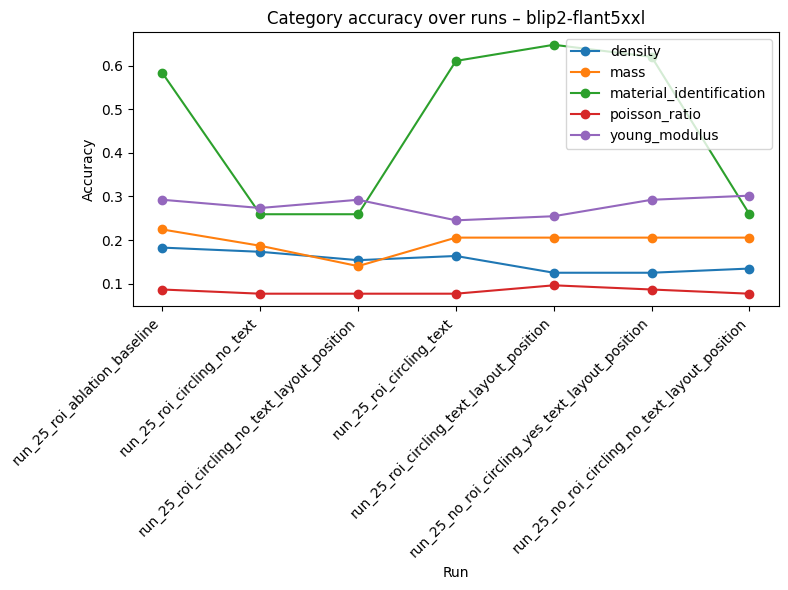

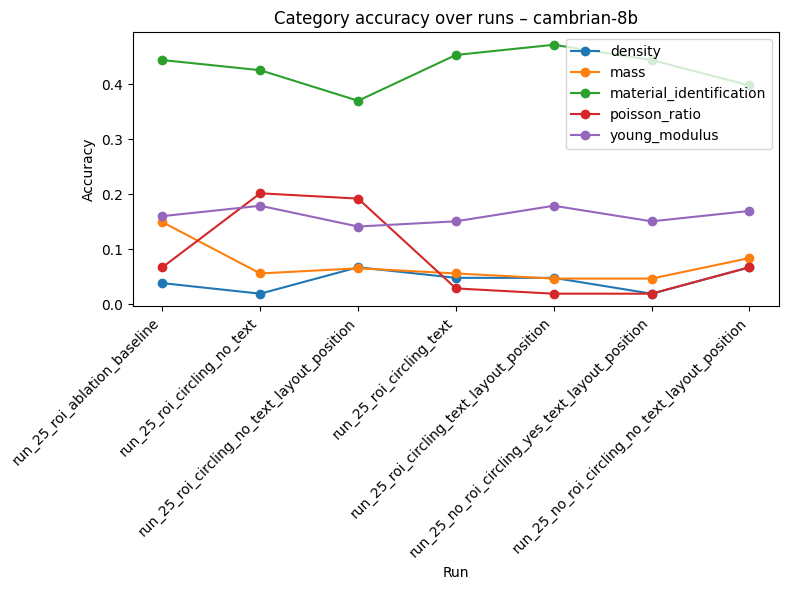

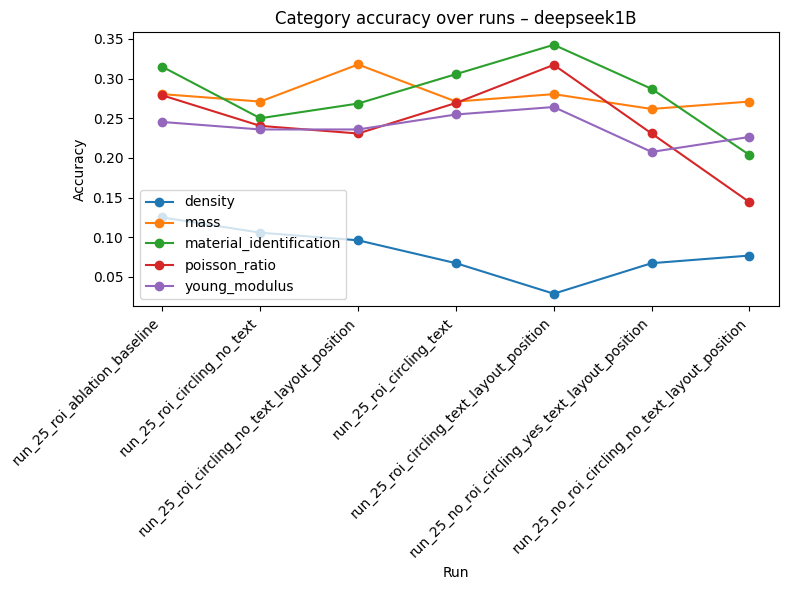

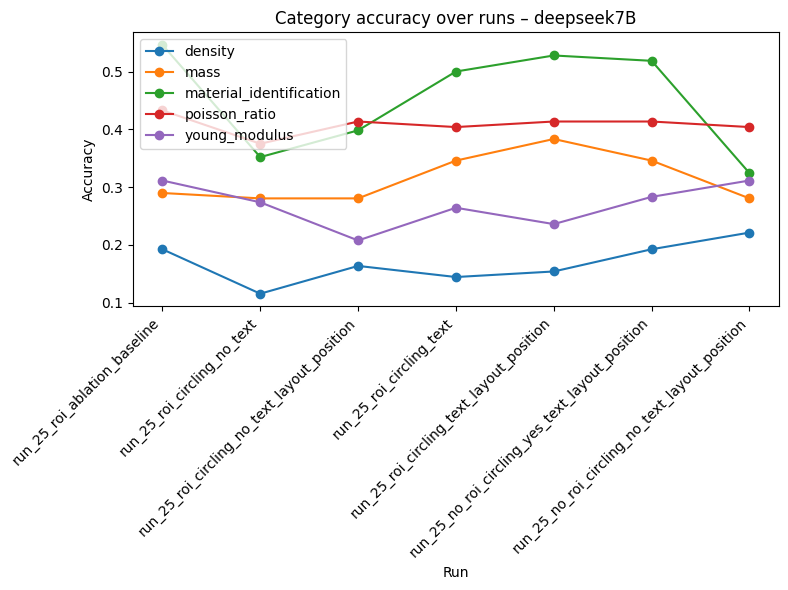

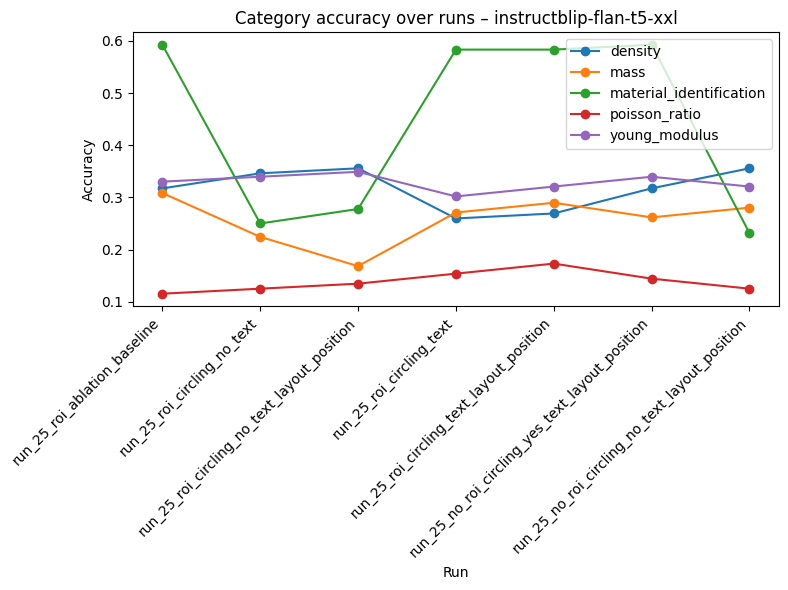

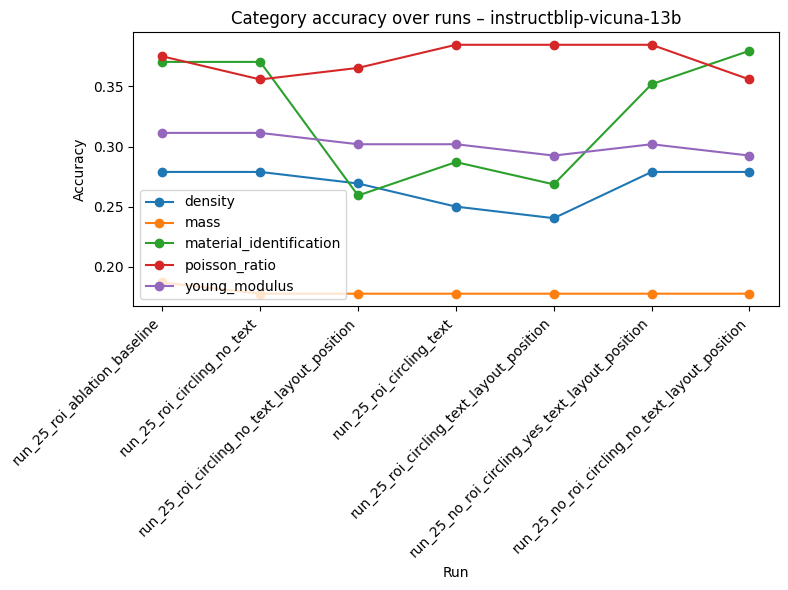

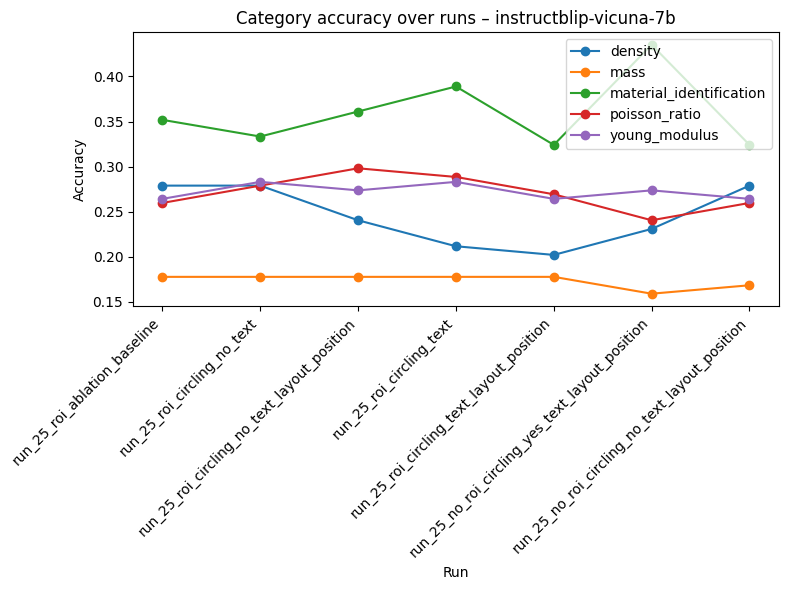

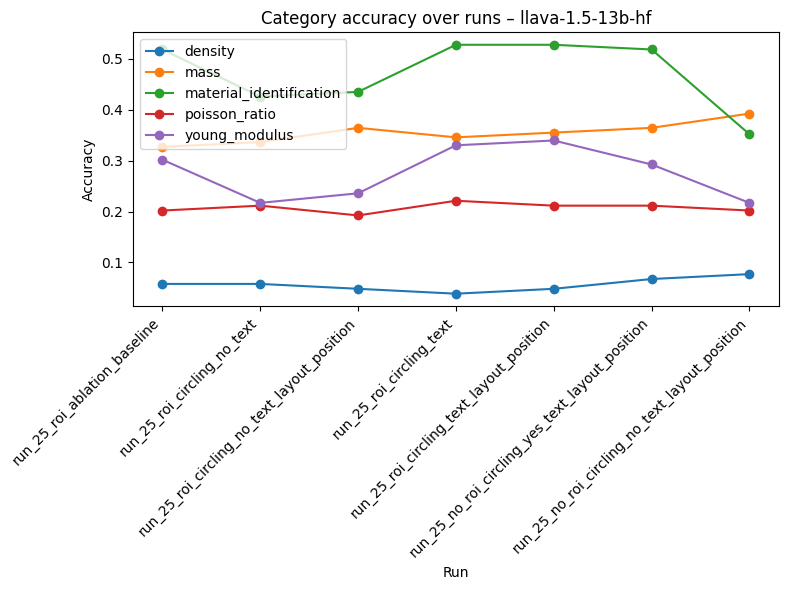

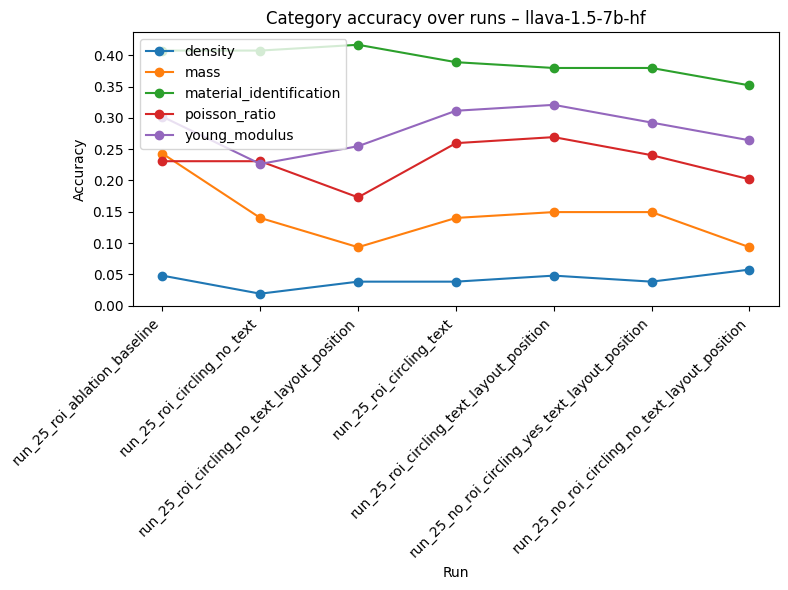

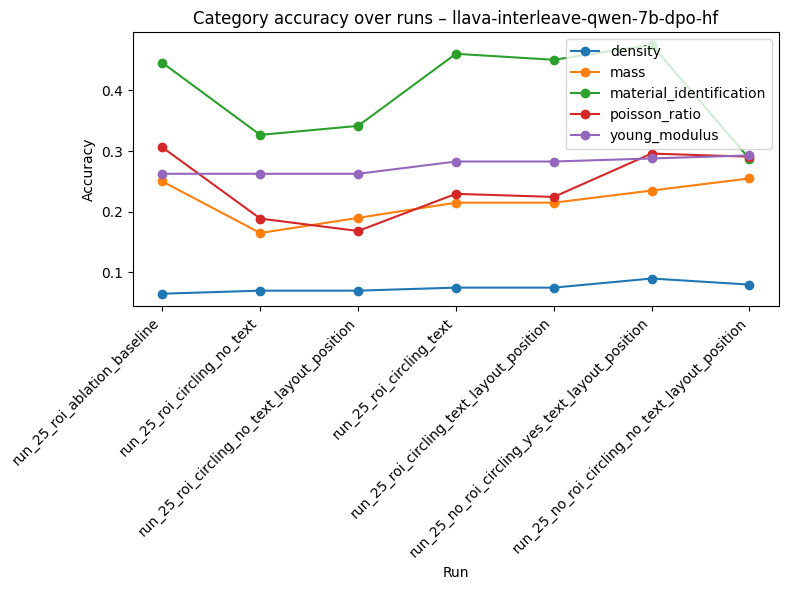

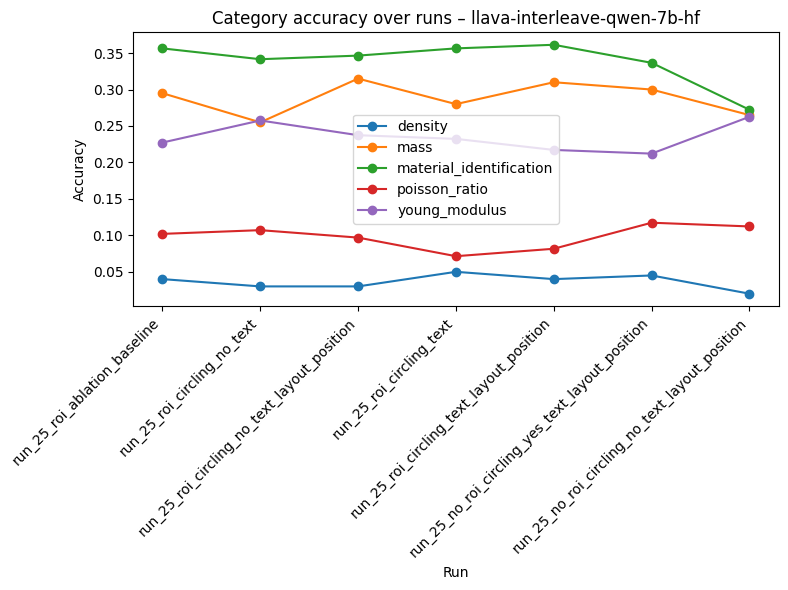

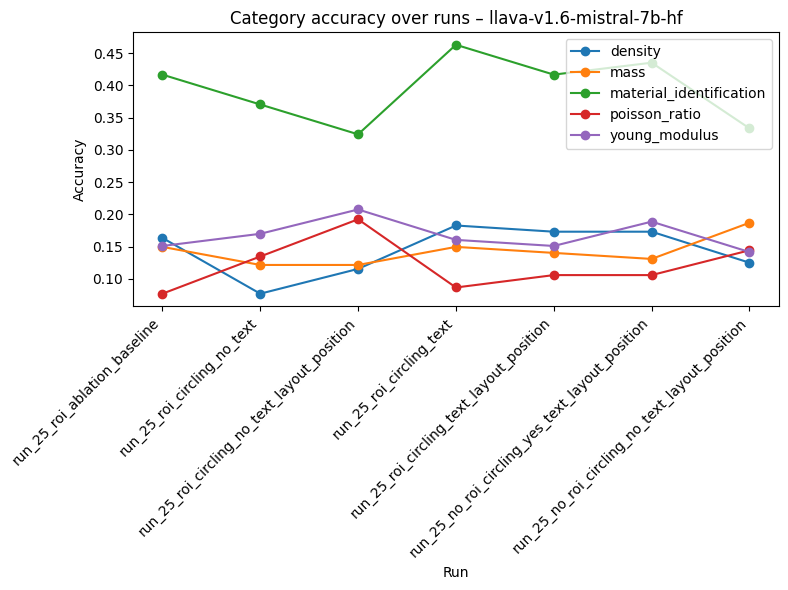

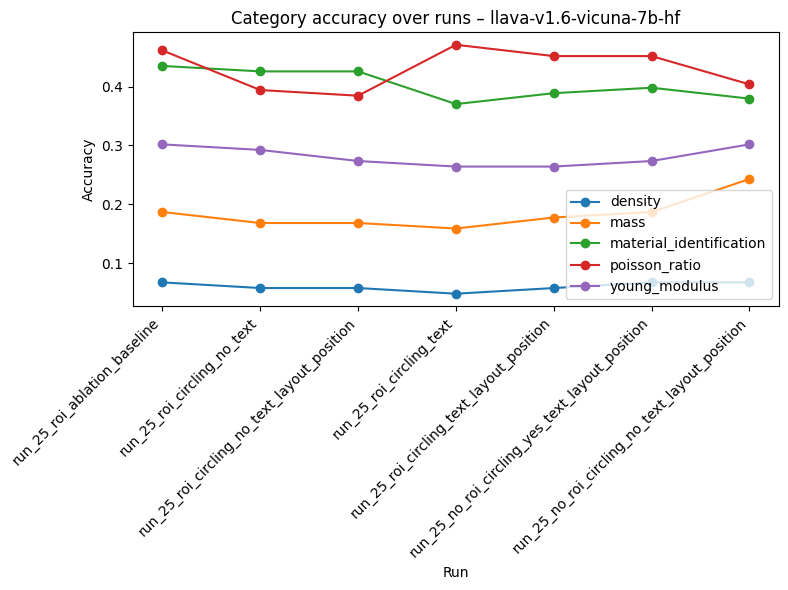

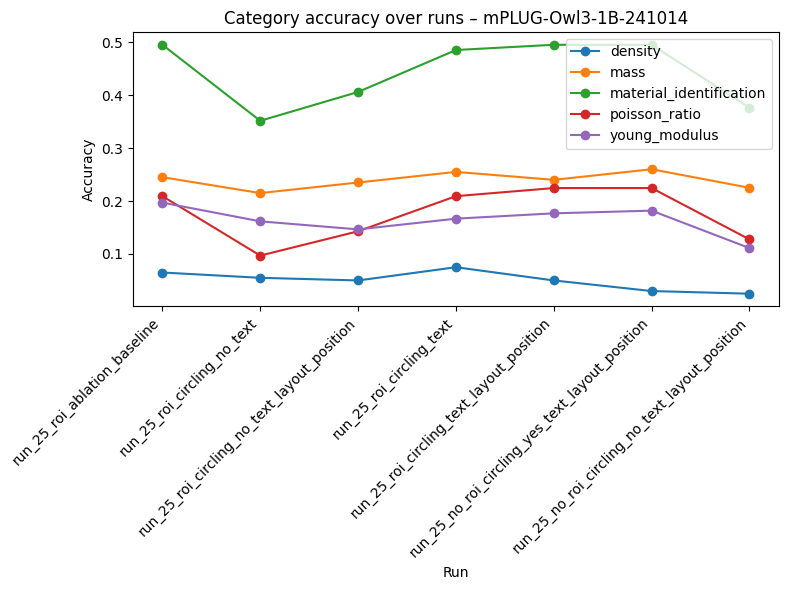

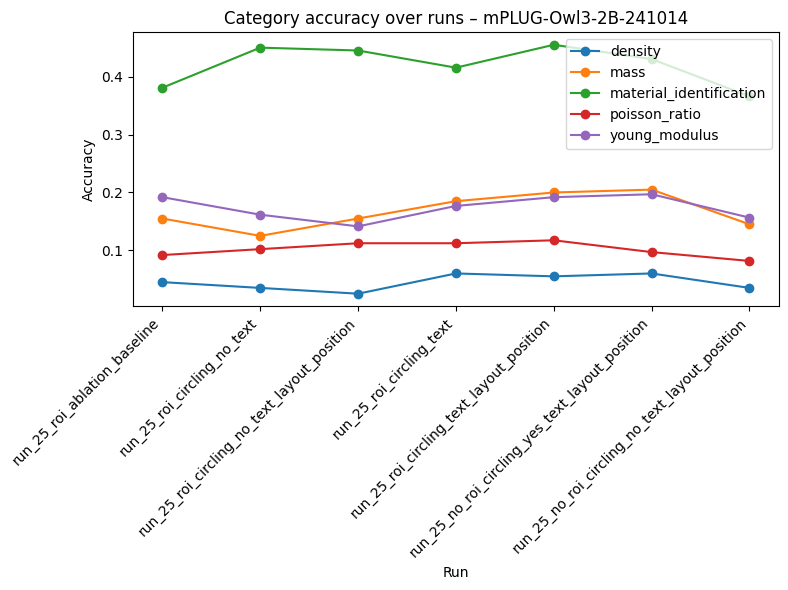

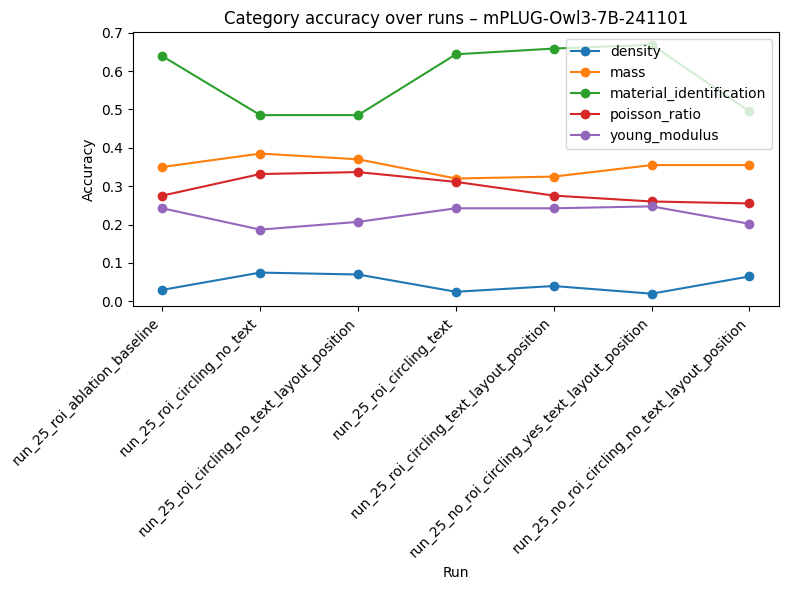

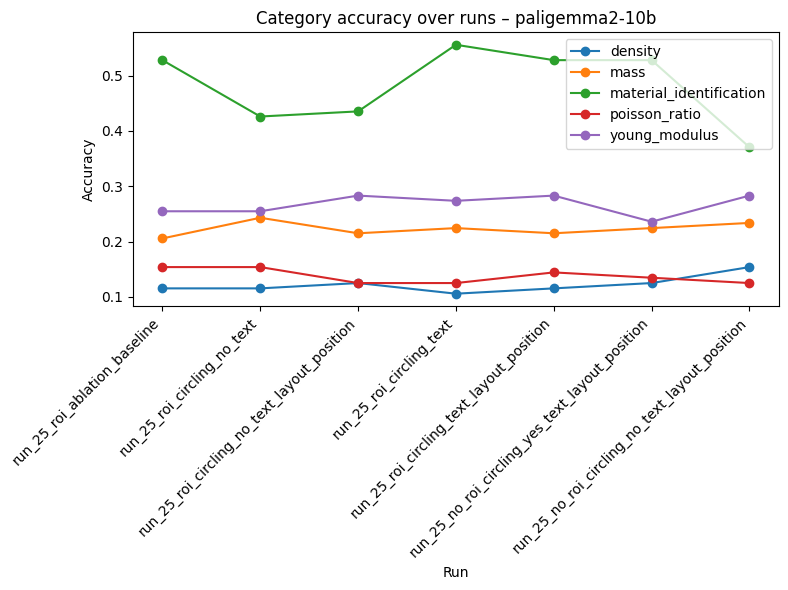

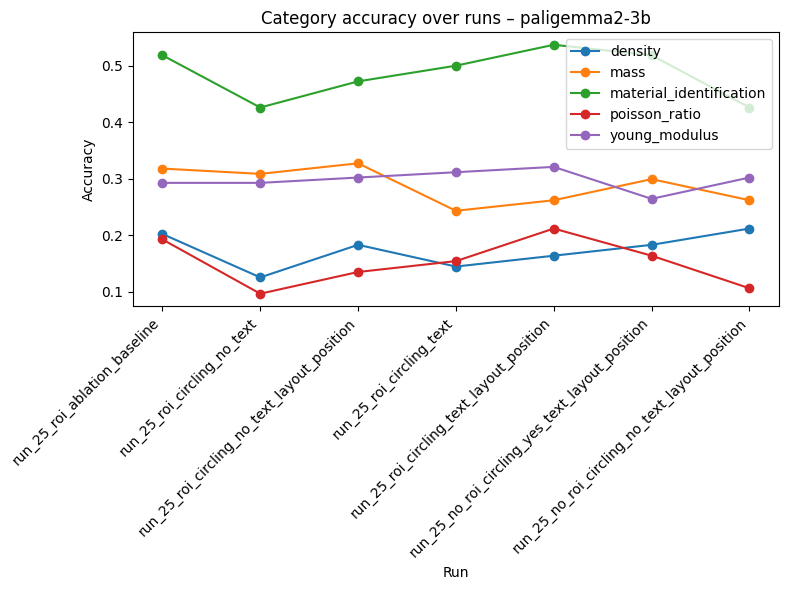

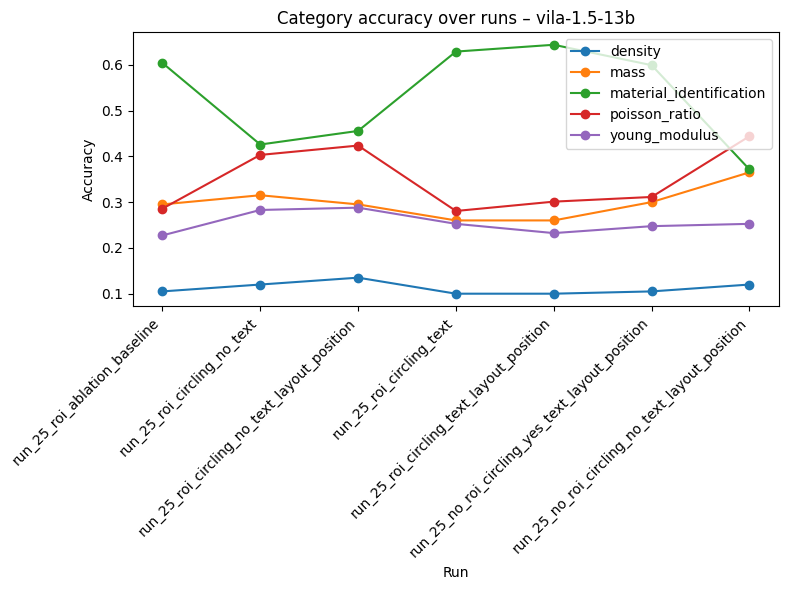

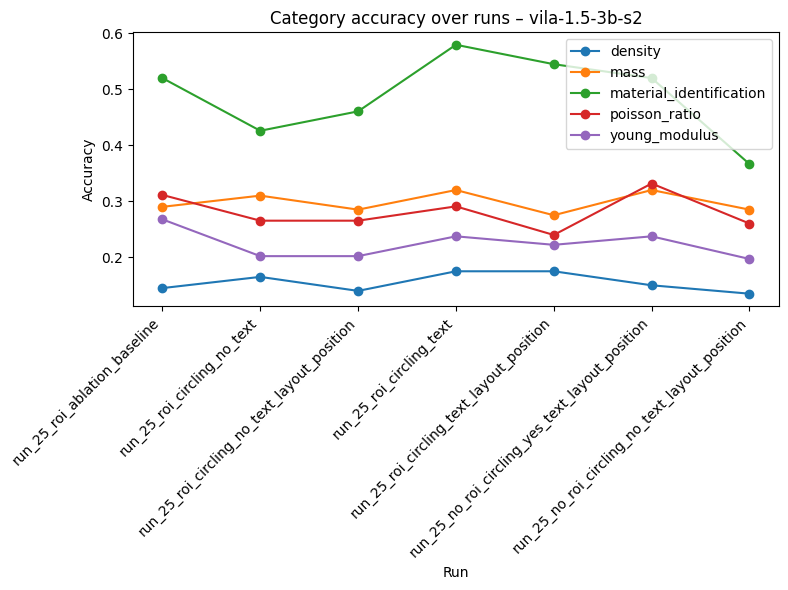

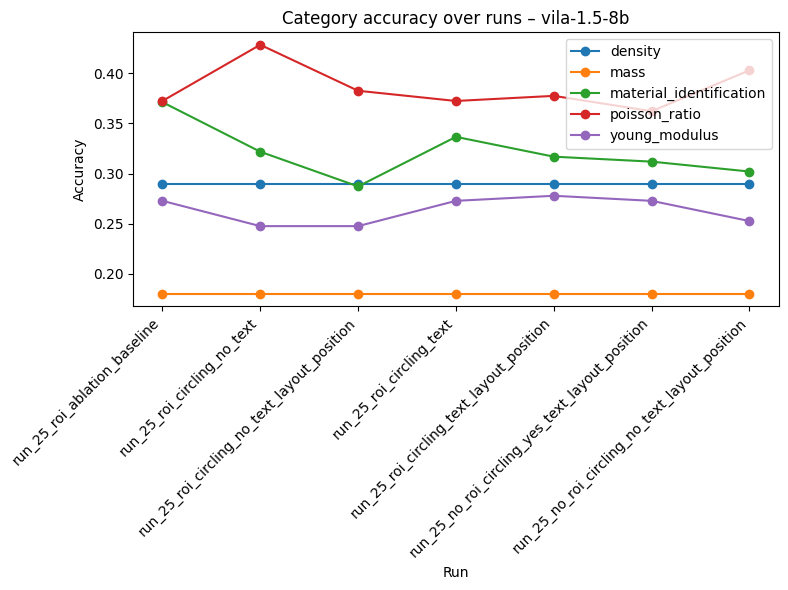

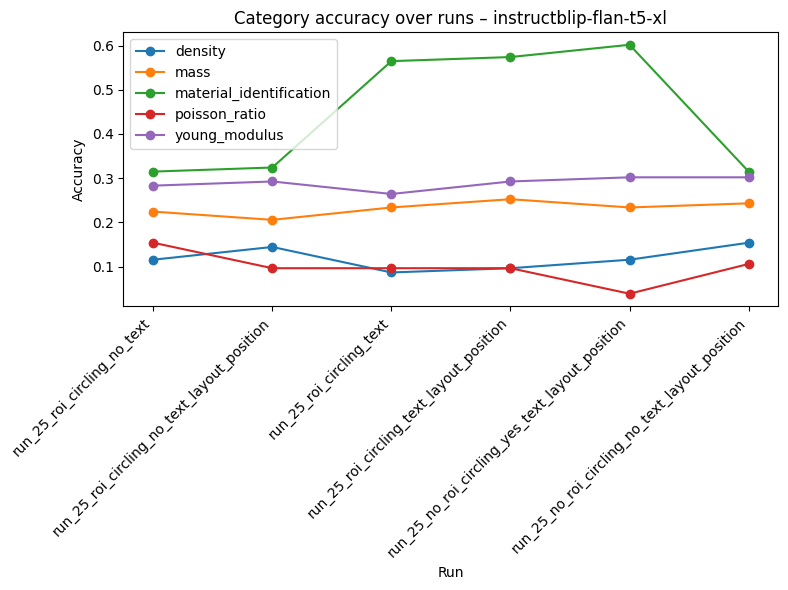

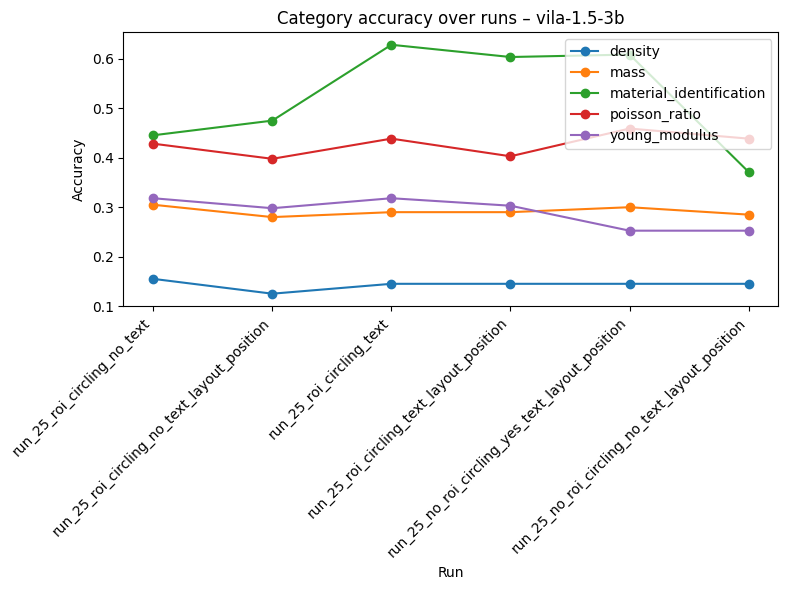

In [ ]:
import matplotlib.pyplot as plt

runs = list(cat_plot_df["run"].unique())
models = list(cat_plot_df["model"].unique())

for model in models:
    df_m = cat_plot_df[cat_plot_df["model"] == model]

    plt.figure(figsize=(8, 6))

    for sub_cat, df_c in df_m.groupby("sub_category"):
        df_c = (
            df_c.set_index("run")
                .reindex(runs)
                .reset_index()
        )

        plt.plot(
            df_c["run"],
            df_c["accuracy"],
            marker="o",
            label=sub_cat
        )

    plt.title(f"Category accuracy over runs – {model}")
    plt.xlabel("Run")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()


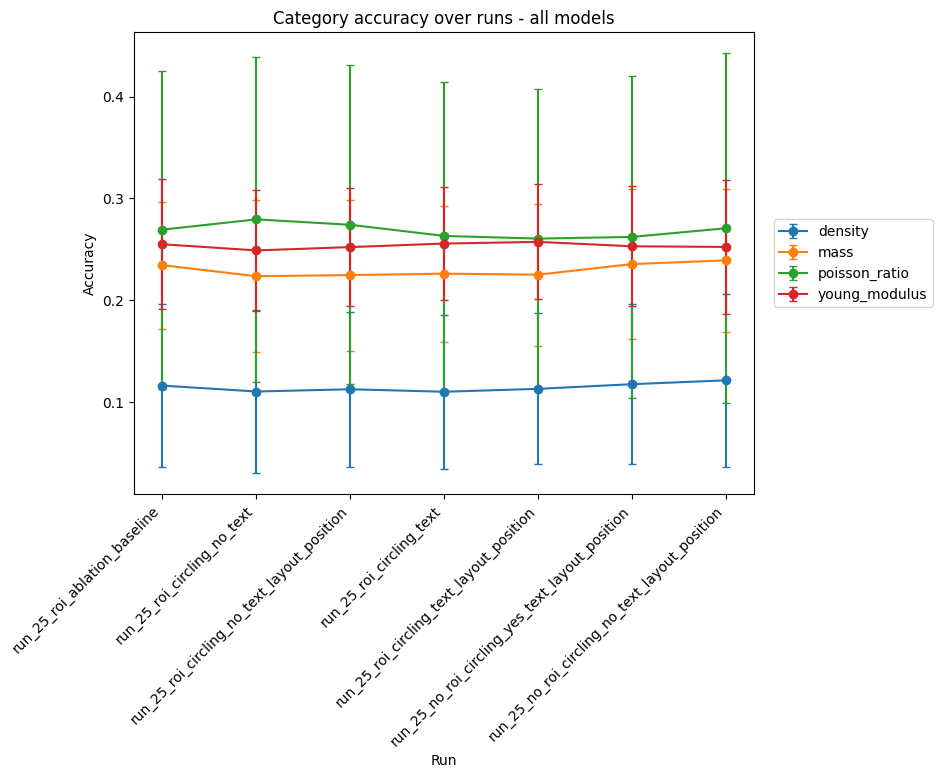

In [42]:
import matplotlib.pyplot as plt

runs = list(cat_plot_df["run"].unique())
models = list(cat_plot_df["model"].unique())

# for model in models:
# df_m = cat_plot_df[cat_plot_df["model"] == model]
df_m = cat_plot_df[cat_plot_df['sub_category'] != "material_identification"]

plt.figure(figsize=(8, 6))


grouped_df = (
    df_m
        .groupby(["sub_category", "run"], as_index=False)
        .agg(
            accuracy=("accuracy", "mean"),
            std=("accuracy", "std")
        )
)

for sub_cat, df_c in grouped_df.groupby("sub_category"):
    df_c = (
        df_c.set_index("run")
            .reindex(runs)
            .reset_index()
    )

    plt.errorbar(
        df_c["run"],
        df_c["accuracy"],
        yerr=df_c["std"],
        marker="o",
        capsize=3,
        label=sub_cat
    )


plt.title(f"Category accuracy over runs - all models")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.show()


In [32]:
grouped_df

,sub_category,run,accuracy
0,density,run_25_no_roi_circling_no_text_layout_position,0.121402
1,density,run_25_no_roi_circling_yes_text_layout_position,0.117602
2,density,run_25_roi_ablation_baseline,0.116200
3,density,run_25_roi_circling_no_text,0.110409
4,density,run_25_roi_circling_no_text_layout_position,0.112619
5,density,run_25_roi_circling_text,0.110172
6,density,run_25_roi_circling_text_layout_position,0.113020
7,mass,run_25_no_roi_circling_no_text_layout_position,0.239221
8,mass,run_25_no_roi_circling_yes_text_layout_position,0.235557
9,mass,run_25_roi_ablation_baseline,0.234462


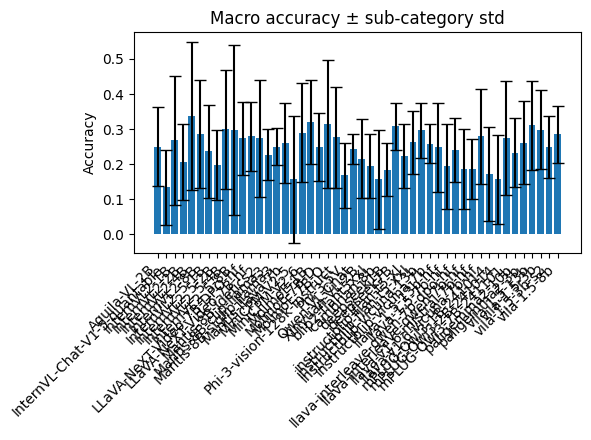

In [26]:
agg = (
    eval_df
    .groupby(["model_id", "sub_category"])["is_correct"]
    .mean()
    .groupby("model_id")
    .agg(mean="mean", std="std")
    .reset_index()
)

plt.figure(figsize=(6, 4.5))
plt.bar(agg["model_id"], agg["mean"], yerr=agg["std"], capsize=4)
plt.ylabel("Accuracy")
plt.title("Macro accuracy ± sub-category std")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [21]:
plot_df

,run,model,macro_accuracy
0,run_25_roi_ablation_baseline,Aquila-VL-2B,0.346625
1,run_25_roi_ablation_baseline,InternVL-Chat-V1-5-quantable,0.196715
2,run_25_roi_ablation_baseline,InternVL2-1B,0.329084
3,run_25_roi_ablation_baseline,InternVL2-2B,0.210889
4,run_25_roi_ablation_baseline,InternVL2-4B,0.333846
...,...,...,...
325,run_25_no_roi_circling_no_text_layout_position,paligemma2-3b,0.261361
326,run_25_no_roi_circling_no_text_layout_position,vila-1.5-13b,0.310538
327,run_25_no_roi_circling_no_text_layout_position,vila-1.5-3b,0.298518
328,run_25_no_roi_circling_no_text_layout_position,vila-1.5-3b-s2,0.248702


In [20]:
categories = plot_df["sub-category"].unique()

for cat in categories:
    df_cat = plot_df[plot_df["sub-category"] == cat]

    plt.figure(figsize=(8, 6))
    for model, df_m in df_cat.groupby("model"):
        df_m = (
            df_m.set_index("run")
                .reindex(runs)
                .reset_index()
        )
        plt.plot(df_m["run"], df_m["accuracy"], marker="o", label=model)

    plt.title(f"Category: {cat}")
    plt.xlabel("Run")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


KeyError: 'sub-category'

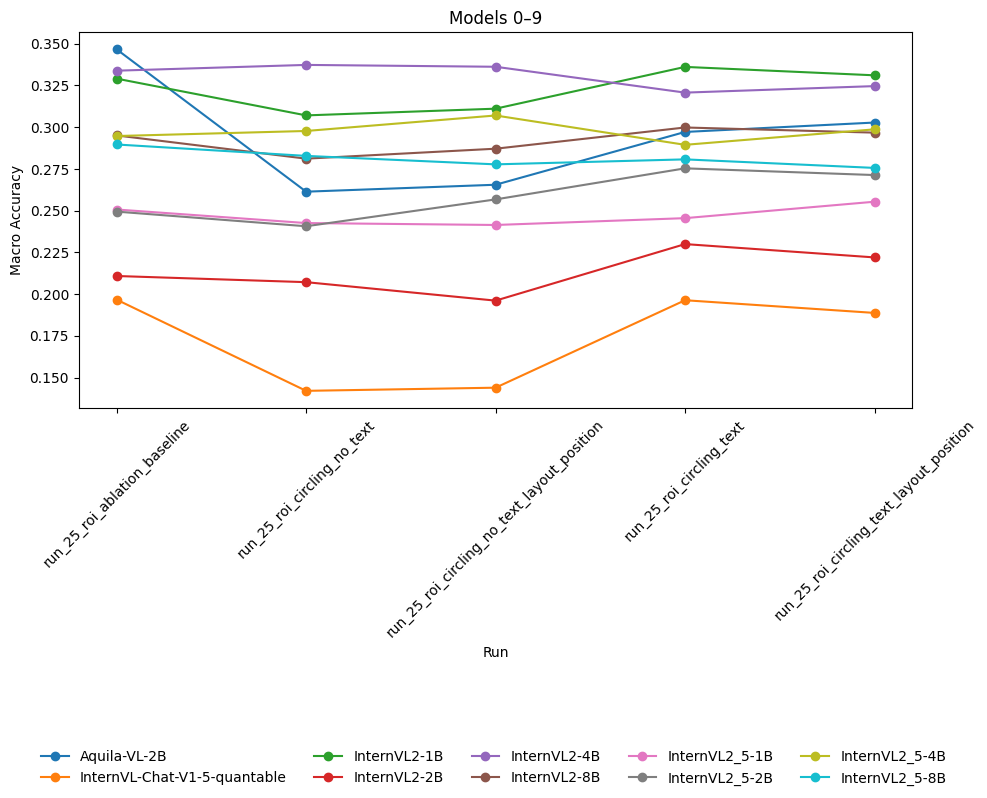

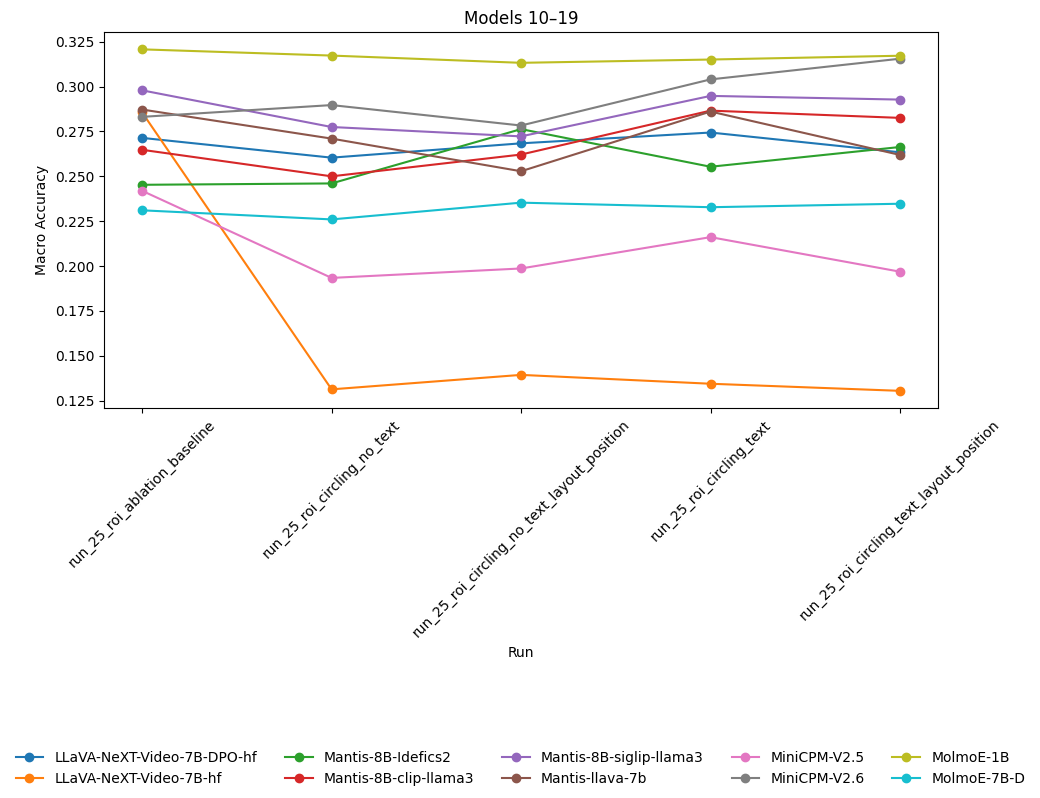

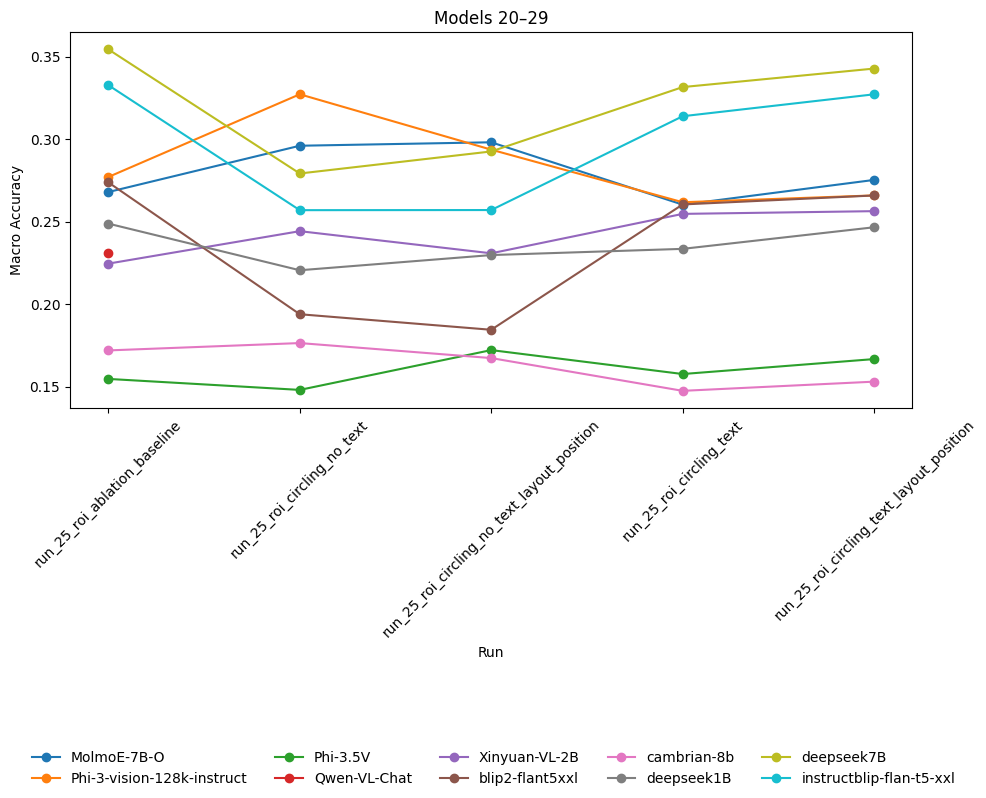

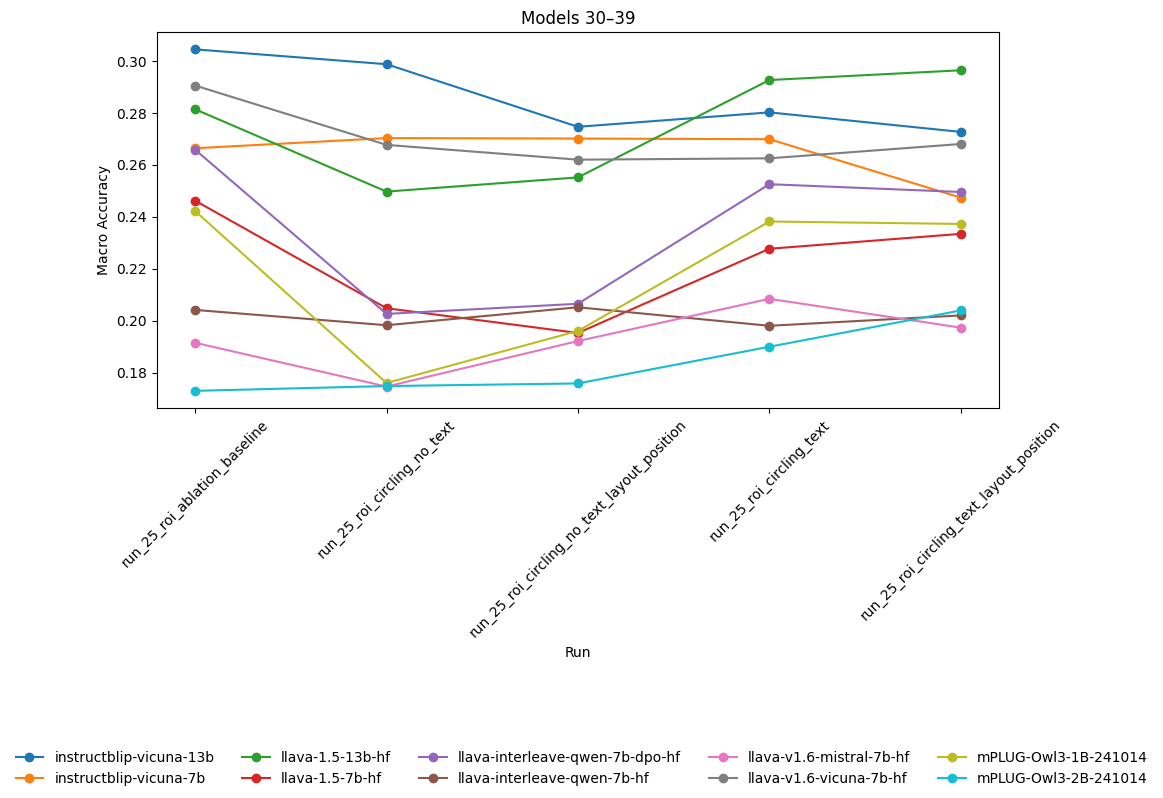

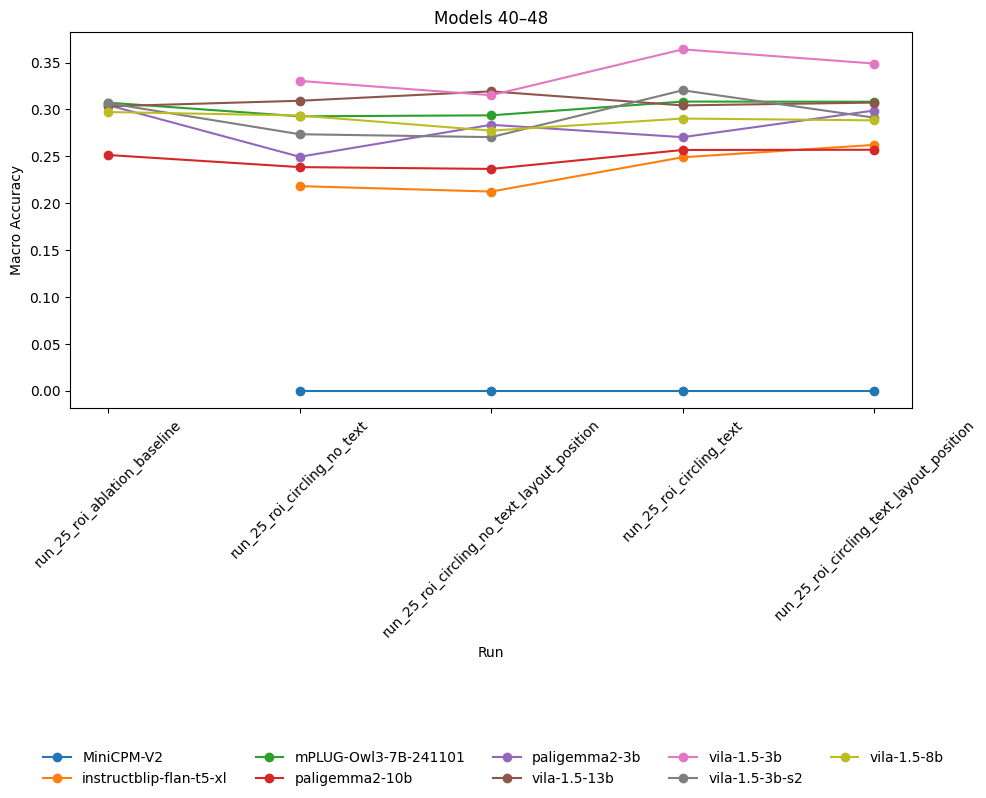

In [50]:
import matplotlib.pyplot as plt
import math

models = list(plot_df["model"].unique())
runs = list(plot_df["run"].unique())

models_per_fig = 10
n_figs = math.ceil(len(models) / models_per_fig)

for i in range(n_figs):
    model_chunk = models[i*models_per_fig:(i+1)*models_per_fig]
    df_chunk = plot_df[plot_df["model"].isin(model_chunk)]

    fig, ax = plt.subplots(figsize=(10, 8))

    handles = []
    labels = []

    for model, df_m in df_chunk.groupby("model"):
        df_m = (
            df_m.set_index("run")
                .reindex(runs)
                .reset_index()
        )
        line, = ax.plot(
            df_m["run"],
            df_m["macro_accuracy"],
            marker="o",
            label=model
        )
        handles.append(line)
        labels.append(model)

    ax.set_xlabel("Run")
    ax.set_ylabel("Macro Accuracy")
    ax.set_title(f"Models {i*models_per_fig}–{min((i+1)*models_per_fig, len(models))-1}")
    ax.tick_params(axis="x", rotation=45)    

    # 🔑 single legend for the whole figure
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=5,
        frameon=False
    )

    fig.tight_layout(rect=[0, 0.15, 1, 1])  # leave space for legend
    plt.show()
